# VPINS — AIA Insurance Challenge: Phân tích khám phá dữ liệu (EDA)

**Mục tiêu kinh doanh.** VPINS muốn nhắm đúng nhóm khách hàng tiềm năng cho bảo hiểm **AIA**, gồm 2 nhiệm vụ:
1. **Dự đoán** — chọn **top 800/4000** khách triển vọng nhất trong `test_data.txt`.
2. **Giải thích** — chỉ ra *vì sao* khách mua, để hỗ trợ chiến dịch bán hàng.

Notebook này thực hiện **EDA toàn diện** + một phần **tín hiệu dự đoán** (mutual information, lift, feature importance, baseline + đường lift/gains mô phỏng top-800) để vừa hiểu dữ liệu vừa bắc cầu sang phần mô hình. Mọi biểu đồ được lưu vào thư mục `figures/` để chèn slide.

> Dữ liệu là bộ **CoIL Challenge 2000 / TIC Benchmark** (nhãn gốc "caravan", đổi tên thành "AIA"): 5.822 khách train, 4.000 khách test, 85 đặc trưng + nhãn.

**Mục lục**
- 0. Cấu hình & metadata
- 1. Nạp dữ liệu & cấu trúc
- 2. Chất lượng dữ liệu
- 3. Biến mục tiêu (target)
- 4. Univariate — phân phối đặc trưng
- 5. Bivariate — quan hệ đặc trưng ↔ target
- 6. Multivariate & tương quan
- 7. Phân khúc khách hàng (actionable)
- 8. Tín hiệu dự đoán (bắc cầu mô hình)
- 9. Tổng kết & chỉ mục biểu đồ
- 10. Insight nâng cao trước Feature Engineering (adversarial, độ phân giải/tổng quát hoá, tín hiệu FE)

## 0. Cấu hình & metadata

Import thư viện, cấu hình font hỗ trợ tiếng Việt cho matplotlib, tạo thư mục `figures/`, và định nghĩa **từ điển tên cột tiếng Việt** + **bảng giải mã** (Appendix A1/A2/A3) để biểu đồ dễ đọc.

In [1]:
import warnings, sys, platform
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# --- Font tiếng Việt: DejaVu Sans (mặc định matplotlib) đã hỗ trợ đủ dấu;
#     ưu tiên font Windows nếu có. axes.unicode_minus=False để hiện dấu trừ đẹp.
plt.rcParams["font.sans-serif"] = ["Segoe UI", "Arial", "Tahoma", "DejaVu Sans"]
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 150
sns.set_theme(style="whitegrid", palette="deep")
PALETTE = {0: "#9aa7b5", 1: "#d1495b"}   # 0 = không mua, 1 = mua AIA

FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)
def savefig(name):
    """Lưu figure hiện tại vào figures/<name>.png (dpi 150, viền sát)."""
    plt.savefig(FIG_DIR / (name + ".png"), dpi=150, bbox_inches="tight")

print("Python", sys.version.split()[0], "|", platform.system())
print("pandas", pd.__version__, "| numpy", np.__version__, "| matplotlib", matplotlib.__version__, "| seaborn", sns.__version__)
print("figures ->", FIG_DIR.resolve())

Python 3.11.5 | Windows
pandas 2.0.3 | numpy 1.26.4 | matplotlib 3.7.2 | seaborn 0.12.2
figures -> C:\Users\phongph9\test\figures


In [2]:
# ===== Metadata: tên cột (tiếng Việt) + nhóm đặc trưng + bảng giải mã =====
SOCIO_NAMES = {
 1:"Phân nhóm KH (subtype)", 2:"Số nhà", 3:"Quy mô hộ TB", 4:"Tuổi TB",
 5:"Nhóm KH chính (main type)", 6:"Công giáo La Mã", 7:"Tin Lành",
 8:"Tôn giáo khác", 9:"Không tôn giáo", 10:"Đã kết hôn", 11:"Sống chung",
 12:"Quan hệ khác", 13:"Độc thân", 14:"Hộ không con", 15:"Hộ có con",
 16:"Học vấn cao", 17:"Học vấn TB", 18:"Học vấn thấp", 19:"Địa vị cao",
 20:"Doanh nhân", 21:"Nông dân", 22:"Quản lý cấp trung", 23:"LĐ có tay nghề",
 24:"LĐ phổ thông", 25:"Tầng lớp A", 26:"Tầng lớp B1", 27:"Tầng lớp B2",
 28:"Tầng lớp C", 29:"Tầng lớp D", 30:"Nhà thuê", 31:"Sở hữu nhà",
 32:"Có 1 ô tô", 33:"Có 2 ô tô", 34:"Không ô tô", 35:"BHYT quốc gia",
 36:"BHYT tư nhân", 37:"Thu nhập <30k", 38:"Thu nhập 30-45k",
 39:"Thu nhập 45-75k", 40:"Thu nhập 75-122k", 41:"Thu nhập >123k",
 42:"Thu nhập TB", 43:"Hạng sức mua",
}
INS_TYPES = [
 "TN bên thứ ba (cá nhân)", "TN bên thứ ba (DN)", "TN bên thứ ba (nông nghiệp)",
 "ô tô", "xe tải nhẹ", "mô tô/scooter", "xe tải lớn", "rơ-moóc", "máy kéo",
 "máy nông nghiệp", "xe máy điện (moped)", "nhân thọ", "tai nạn cá nhân",
 "tai nạn gia đình", "khuyết tật", "cháy nổ", "ván lướt sóng", "thuyền",
 "xe đạp", "tài sản", "an sinh xã hội",
]
NAME = {str(c): nm for c, nm in SOCIO_NAMES.items()}
for i, t in enumerate(INS_TYPES):
    NAME[str(44 + i)] = "Đóng phí BH " + t   # cột 44..64
    NAME[str(65 + i)] = "Số HĐ BH " + t       # cột 65..85

GROUP = {}
for c in range(1, 43):  GROUP[str(c)] = "Nhân khẩu học"
GROUP["43"] = "Sức mua"
for c in range(44, 65): GROUP[str(c)] = "Đóng phí (Contribution)"
for c in range(65, 86): GROUP[str(c)] = "Số HĐ (Number)"

# Appendix A1 — Customer subtype (giữ tên gốc tiếng Anh, mang tính marketing)
A1 = {1:"High income, expensive child", 2:"Very important provincials", 3:"High status seniors",
 4:"Affluent senior apartments", 5:"Mixed seniors", 6:"Career and childcare", 7:"Double income no kids",
 8:"Middle class families", 9:"Modern complete families", 10:"Stable family", 11:"Family starters",
 12:"Affluent young families", 13:"Young all american family", 14:"Junior cosmopolitan",
 15:"Senior cosmopolitans", 16:"Students in apartments", 17:"Fresh masters in the city", 18:"Single youth",
 19:"Suburban youth", 20:"Ethnically diverse", 21:"Young urban have-nots", 22:"Mixed apartment dwellers",
 23:"Young and rising", 24:"Young low educated", 25:"Young seniors in the city", 26:"Own home elderly",
 27:"Seniors in apartments", 28:"Residential elderly", 29:"Porchless seniors", 30:"Religious elderly singles",
 31:"Low income catholics", 32:"Mixed seniors (2)", 33:"Lower class large families", 34:"Large family employed child",
 35:"Village families", 36:"Couples with teens", 37:"Mixed small town dwellers", 38:"Traditional families",
 39:"Large religious families", 40:"Large family farms", 41:"Mixed rurals"}
# Appendix A2 — Avg age band
A2 = {1:"20-30", 2:"30-40", 3:"40-50", 4:"50-60", 5:"60-70", 6:"70-80"}
# Appendix A3 — Customer main type (Việt hoá)
A3 = {1:"Hedonist thành đạt", 2:"Người vươn lên", 3:"Gia đình trung bình", 4:"Độc lập sự nghiệp",
 5:"Sống sung túc", 6:"Cao tuổi an nhàn", 7:"Nghỉ hưu & sùng đạo", 8:"Gia đình con đã lớn",
 9:"Gia đình bảo thủ", 10:"Nông dân"}

def disp(col):
    """Tên hiển thị tiếng Việt cho 1 cột."""
    return NAME.get(str(col), str(col))

print("Đã định nghĩa metadata cho", len(NAME), "đặc trưng. Nhóm:", sorted(set(GROUP.values())))

Đã định nghĩa metadata cho 85 đặc trưng. Nhóm: ['Nhân khẩu học', 'Số HĐ (Number)', 'Sức mua', 'Đóng phí (Contribution)']


## 1. Nạp dữ liệu & cấu trúc tổng quan

In [3]:
train = pd.read_csv("data/train_data.txt")
test  = pd.read_csv("data/test_data.txt")

TARGET   = "86"
FEATURES = [str(i) for i in range(1, 86)]
SOCIO    = [str(i) for i in range(1, 43)]
PP       = ["43"]
CONTRIB  = [str(i) for i in range(44, 65)]
NUMBER   = [str(i) for i in range(65, 86)]

print("train:", train.shape, "| test:", test.shape)
print("Số đặc trưng:", len(FEATURES), "| target =", TARGET)
train.head()

train: (5822, 87) | test: (4000, 86)
Số đặc trưng: 85 | target = 86


,ID,1,2,3,4,5,6,7,8,9,...,77,78,79,80,81,82,83,84,85,86
0,1,33,1,3,2,8,0,5,1,3,...,0,0,0,1,0,0,0,0,0,0
1,2,37,1,2,2,8,1,4,1,4,...,0,0,0,1,0,0,0,0,0,0
2,3,37,1,2,2,8,0,4,2,4,...,0,0,0,1,0,0,0,0,0,0
3,4,9,1,3,3,3,2,3,2,4,...,0,0,0,1,0,0,0,0,0,0
4,5,40,1,4,2,10,1,4,1,4,...,0,0,0,1,0,0,0,0,0,0


In [4]:
# Kiểu dữ liệu, bộ nhớ, đối chiếu schema train vs test
print("--- dtypes (giá trị duy nhất) ---", train.dtypes.unique())
print("Bộ nhớ train: %.2f MB | test: %.2f MB" % (train.memory_usage(deep=True).sum()/1e6,
                                                  test.memory_usage(deep=True).sum()/1e6))
only_train = set(train.columns) - set(test.columns)
print("Cột chỉ có ở train (test thiếu):", only_train, "-> đúng như kỳ vọng (test không có nhãn).")
print("Test có đủ 85 đặc trưng giống train:", set(FEATURES).issubset(test.columns))

--- dtypes (giá trị duy nhất) --- [dtype('int64')]
Bộ nhớ train: 4.05 MB | test: 2.75 MB
Cột chỉ có ở train (test thiếu): {'86'} -> đúng như kỳ vọng (test không có nhãn).
Test có đủ 85 đặc trưng giống train: True


## 2. Chất lượng dữ liệu

Kiểm tra giá trị thiếu, dòng trùng, cột hằng số, giá trị ngoài dải codebook, và so sánh sơ bộ phân phối train vs test (drift).

In [5]:
quality = {
 "Thiếu (train)": int(train.isna().sum().sum()),
 "Thiếu (test)": int(test.isna().sum().sum()),
 "Dòng trùng hoàn toàn (train, theo đặc trưng)": int(train[FEATURES].duplicated().sum()),
 "Cột hằng số (zero-variance)": int((train[FEATURES].nunique() <= 1).sum()),
}
for k, v in quality.items():
    print(f"{k}: {v}")
print("\nSố giá trị duy nhất mỗi cột (mô tả): min=%d, max=%d" % (train[FEATURES].nunique().min(),
                                                                 train[FEATURES].nunique().max()))
print("Cột có >10 mức:", [disp(c) for c in FEATURES if train[c].nunique() > 10])

Thiếu (train): 0
Thiếu (test): 0
Dòng trùng hoàn toàn (train, theo đặc trưng): 651
Cột hằng số (zero-variance): 0

Số giá trị duy nhất mỗi cột (mô tả): min=2, max=40
Cột có >10 mức: ['Phân nhóm KH (subtype)']


## 2b. Dòng trùng theo đặc trưng — có nên drop trước khi train không?

Phần 2 cho thấy **651 dòng trùng hoàn toàn theo 85 đặc trưng**. Có nên `drop_duplicates()` không? **KHÔNG** — và đây là lý do.

**651 dòng "thừa" đó đến từ đâu?** Chúng nằm trong **510 nhóm trùng** (mỗi nhóm là tập khách có 85 đặc trưng y hệt nhau), phân bố theo kích thước: **405 nhóm 2 người, 77 nhóm 3 người, 21 nhóm 4 người, 6 nhóm 5 người, 1 nhóm 6 người** — xem **(a)** và bảng **(f)**. `drop_duplicates` chỉ giữ 1 dòng mỗi nhóm nên bỏ đi 651 dòng (= tổng (kích thước−1) của các nhóm).

**Vì sao dữ liệu này tất yếu trùng (không phải lỗi nhập liệu):**
- Cột 1–42 (nhân khẩu) **suy từ mã bưu chính** → mọi khách cùng vùng có giá trị y hệt.
- Cột 43–85 bị **rời rạc hoá thô** (mức 0–9). Nên hai *khách hàng thật khác nhau* rất dễ trùng cả 85 đặc trưng — đây là **giới hạn độ phân giải của dữ liệu**, không phải bản ghi lặp.

Các biểu đồ chứng minh drop sẽ **xoá đúng tín hiệu xếp hạng** mà bài toán top-800 cần:
- **(b)** 49/510 nhóm là **"mâu thuẫn nhãn"** (cùng đặc trưng nhưng vừa có người mua vừa không) → đó chính là **xác suất mua của từng profile**.
- **(c)** Drop `keep='first'` **ép xác suất profile về 0% hoặc 100%**, phá huỷ các giá trị trung gian (25%, 50%, 67%…).
- **(d)** Drop vứt bỏ **~32/348 người đã thực sự mua (~9%)** — quá đắt khi chỉ có ~6% là dương.
- **(e)** **18.6%** dòng test có profile trùng train → mô hình **chắc chắn gặp lại** khi chấm điểm.

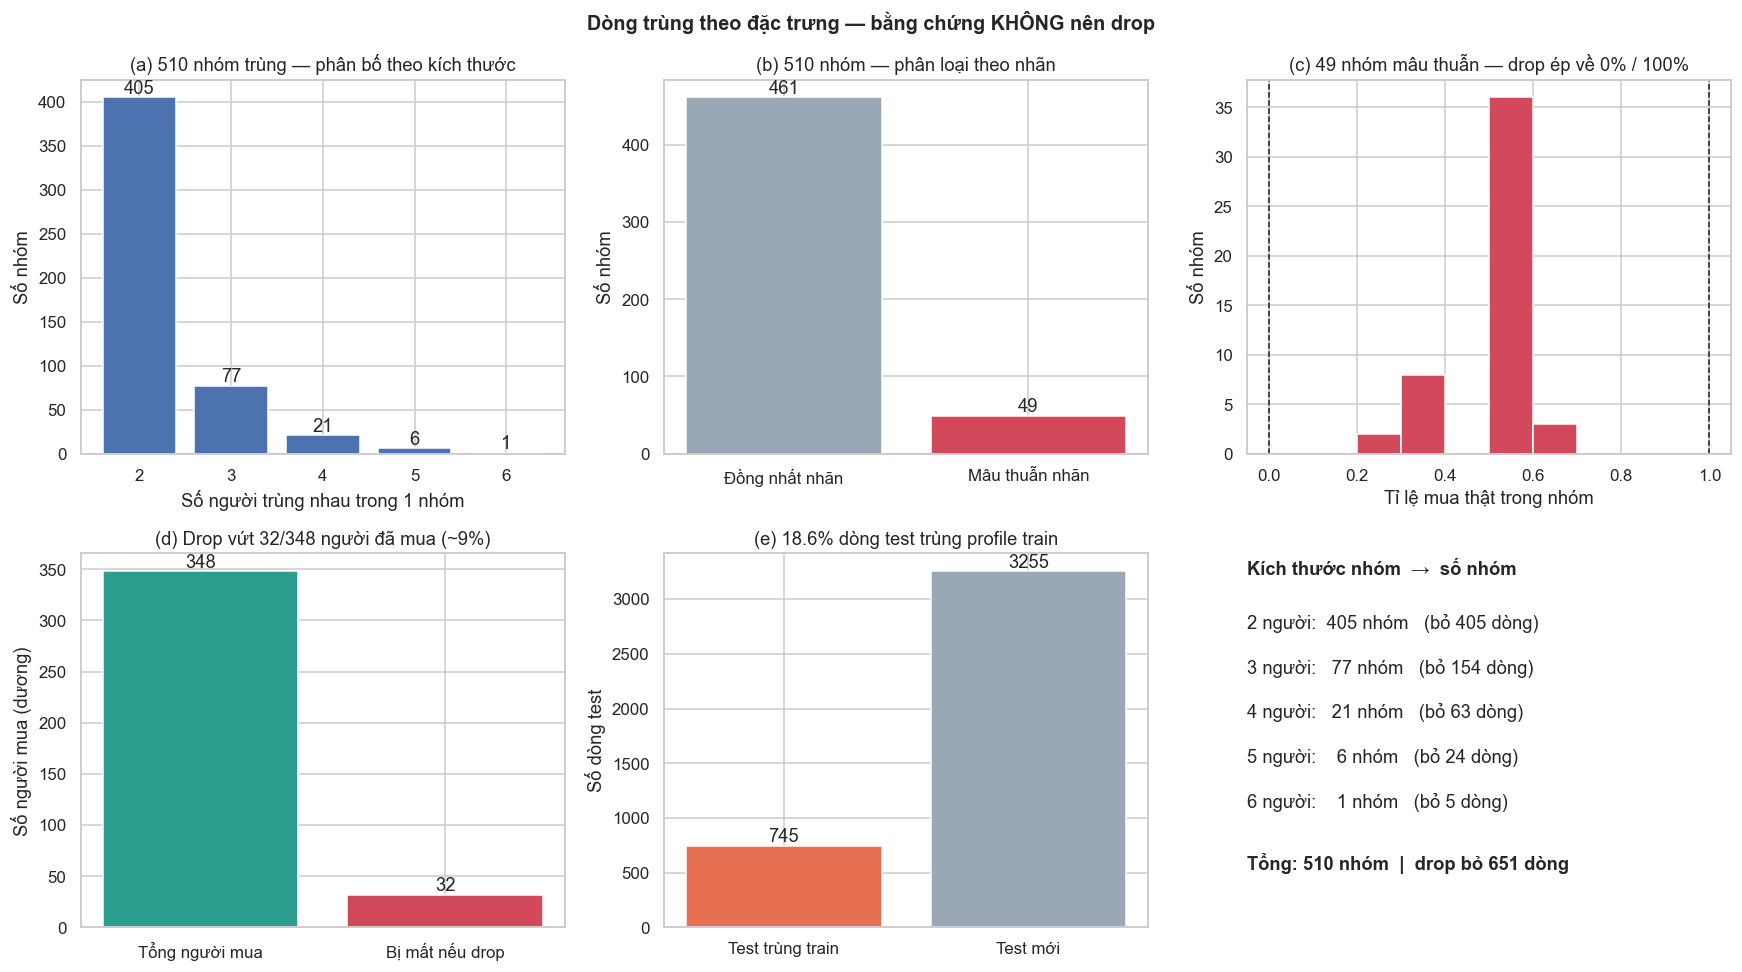

Phân bố kích thước nhóm trùng (số người trong nhóm -> số nhóm):
  2 người trùng: 405 nhóm  (chiếm 810 dòng, dư 405 dòng)
  3 người trùng:  77 nhóm  (chiếm 231 dòng, dư 154 dòng)
  4 người trùng:  21 nhóm  (chiếm 84 dòng, dư 63 dòng)
  5 người trùng:   6 nhóm  (chiếm 30 dòng, dư 24 dòng)
  6 người trùng:   1 nhóm  (chiếm 6 dòng, dư 5 dòng)
Tổng: 510 nhóm trùng gồm 1161 dòng; drop_duplicates bỏ 651 dòng (còn 5171).
Phân loại nhãn: 461 nhóm đồng nhất | 49 nhóm mâu thuẫn.
Drop làm MẤT 32/348 người mua (~9.2%); base rate 0.0598 -> 0.0611.
=> Giữ nguyên dữ liệu. Lo rò rỉ CV thì dùng GroupKFold theo profile (KHÔNG drop).


In [6]:
# ===== 2b. Dòng trùng: bằng chứng KHÔNG nên drop =====
_g = train.groupby(FEATURES)[TARGET]
_grp = pd.DataFrame({"n": _g.size(), "n_pos": _g.sum()})
_multi = _grp[_grp["n"] > 1].copy()
_multi["rate"] = _multi["n_pos"] / _multi["n"]
_conflict = _multi[(_multi["n_pos"] > 0) & (_multi["n_pos"] < _multi["n"])]
n_conf = len(_conflict); n_same = len(_multi) - n_conf

_dup_drop = train[train[FEATURES].duplicated(keep="first")]
n_drop = len(_dup_drop); pos_lost = int(_dup_drop[TARGET].sum())
pos_total = int(train[TARGET].sum())
base_before = train[TARGET].mean()
base_after = train[~train[FEATURES].duplicated(keep="first")][TARGET].mean()

_train_prof = set(train[FEATURES].itertuples(index=False, name=None))
n_test_in_train = sum(p in _train_prof for p in test[FEATURES].itertuples(index=False, name=None))
pct_test = n_test_in_train / len(test) * 100

# Phân bố kích thước nhóm trùng (2 người, 3 người, ...)
_size_dist = _multi["n"].value_counts().sort_index()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
c0, c1 = PALETTE[0], PALETTE[1]

# (a) phân bố kích thước nhóm
ax = axes[0, 0]
b = ax.bar([str(int(s)) for s in _size_dist.index], _size_dist.values, color="#4c72b0")
ax.bar_label(b)
ax.set_xlabel("Số người trùng nhau trong 1 nhóm"); ax.set_ylabel("Số nhóm")
ax.set_title("(a) %d nhóm trùng — phân bố theo kích thước" % len(_multi))

# (b) đồng nhất vs mâu thuẫn nhãn
ax = axes[0, 1]
b = ax.bar(["Đồng nhất nhãn", "Mâu thuẫn nhãn"], [n_same, n_conf], color=[c0, c1])
ax.bar_label(b); ax.set_ylabel("Số nhóm")
ax.set_title("(b) %d nhóm — phân loại theo nhãn" % len(_multi))

# (c) histogram tỉ lệ mua trong nhóm mâu thuẫn
ax = axes[0, 2]
ax.hist(_conflict["rate"], bins=np.linspace(0, 1, 11), color=c1, edgecolor="white")
ax.axvline(0, color="k", ls="--", lw=1); ax.axvline(1, color="k", ls="--", lw=1)
ax.set_xlabel("Tỉ lệ mua thật trong nhóm"); ax.set_ylabel("Số nhóm")
ax.set_title("(c) %d nhóm mâu thuẫn — drop ép về 0%% / 100%%" % n_conf)

# (d) người mua bị mất nếu drop
ax = axes[1, 0]
b = ax.bar(["Tổng người mua", "Bị mất nếu drop"], [pos_total, pos_lost], color=["#2a9d8f", c1])
ax.bar_label(b); ax.set_ylabel("Số người mua (dương)")
ax.set_title("(d) Drop vứt %d/%d người đã mua (~%.0f%%)" % (pos_lost, pos_total, pos_lost / pos_total * 100))

# (e) trùng ở cả test
ax = axes[1, 1]
b = ax.bar(["Test trùng train", "Test mới"], [n_test_in_train, len(test) - n_test_in_train], color=["#e76f51", c0])
ax.bar_label(b); ax.set_ylabel("Số dòng test")
ax.set_title("(e) %.1f%% dòng test trùng profile train" % pct_test)

# (f) bảng tóm tắt kích thước nhóm
ax = axes[1, 2]; ax.axis("off")
ax.text(0.0, 0.98, "Kích thước nhóm  →  số nhóm", va="top", fontsize=12, weight="bold")
_yy = 0.84
for s, cnt in _size_dist.items():
    ax.text(0.0, _yy, "%d người:  %3d nhóm   (bỏ %d dòng)" % (int(s), int(cnt), (int(s) - 1) * int(cnt)),
            va="top", fontsize=12); _yy -= 0.12
ax.text(0.0, _yy - 0.04, "Tổng: %d nhóm  |  drop bỏ %d dòng" % (len(_multi), n_drop),
        va="top", fontsize=12, weight="bold")

plt.suptitle("Dòng trùng theo đặc trưng — bằng chứng KHÔNG nên drop", fontsize=13, weight="bold")
plt.tight_layout(); savefig("02b_duplicates_keep_decision"); plt.show()

print("Phân bố kích thước nhóm trùng (số người trong nhóm -> số nhóm):")
for s, cnt in _size_dist.items():
    print("  %d người trùng: %3d nhóm  (chiếm %d dòng, dư %d dòng)" % (int(s), int(cnt), int(s) * int(cnt), (int(s) - 1) * int(cnt)))
print("Tổng: %d nhóm trùng gồm %d dòng; drop_duplicates bỏ %d dòng (còn %d)." % (len(_multi), int(_multi["n"].sum()), n_drop, len(train) - n_drop))
print("Phân loại nhãn: %d nhóm đồng nhất | %d nhóm mâu thuẫn." % (n_same, n_conf))
print("Drop làm MẤT %d/%d người mua (~%.1f%%); base rate %.4f -> %.4f." % (pos_lost, pos_total, pos_lost / pos_total * 100, base_before, base_after))
print("=> Giữ nguyên dữ liệu. Lo rò rỉ CV thì dùng GroupKFold theo profile (KHÔNG drop).")

**Kết luận.** Không `drop_duplicates`. Các dòng trùng là khách hàng thật và mang **xác suất mua theo profile** — chính là tín hiệu mà xếp hạng top-800 dựa vào. Nếu muốn đánh giá CV nghiêm ngặt hơn, dùng **GroupKFold theo profile** (giữ nguyên dữ liệu, chỉ đảm bảo các dòng cùng profile không nằm cả ở train lẫn validation).

In [7]:
# Kiểm tra giá trị ngoài dải codebook kỳ vọng
issues = []
# subtype 1..41
bad = train[~train["1"].between(1, 41)]; issues.append(("subtype (1-41)", len(bad)))
# main type 1..10, age 1..6
issues.append(("main type (1-10)", int((~train["5"].between(1, 10)).sum())))
issues.append(("age (1-6)", int((~train["4"].between(1, 6)).sum())))
# contribution & number 0..9
for c in CONTRIB:
    issues += [("contrib>9", int((train[c] > 9).sum()))] if (train[c] > 9).any() else []
oor_num = int((train[NUMBER] > 9).sum().sum())
oor_con = int((train[CONTRIB] > 9).sum().sum())
print("Giá trị ngoài dải:")
for k, v in issues[:3]:
    print(f"  {k}: {v}")
print(f"  contribution (44-64) >9: {oor_con}")
print(f"  number (65-85) >9: {oor_num}")
print("=> Dữ liệu sạch, đúng codebook." if oor_num == 0 and oor_con == 0 else "=> Có giá trị bất thường, cần xem lại.")

Giá trị ngoài dải:
  subtype (1-41): 0
  main type (1-10): 0
  age (1-6): 0
  contribution (44-64) >9: 0
  number (65-85) >9: 0
=> Dữ liệu sạch, đúng codebook.


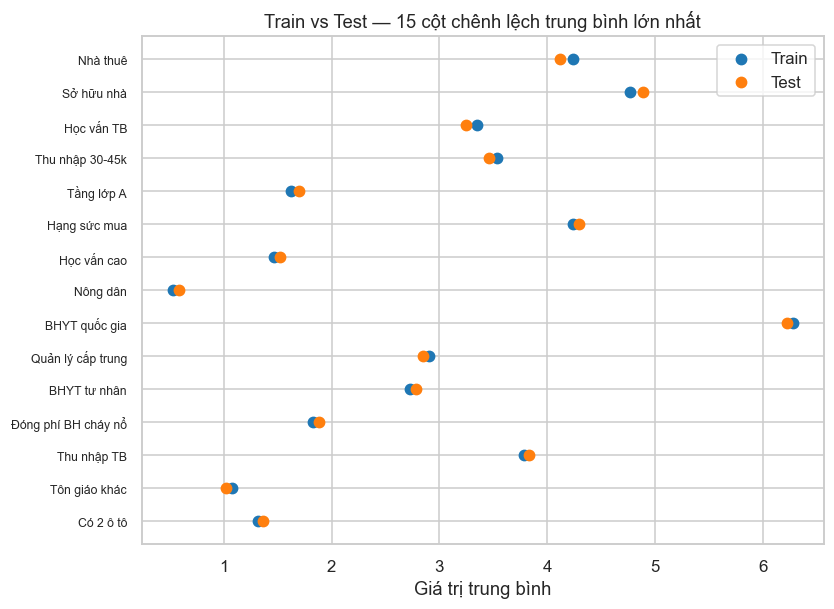

Chênh lệch trung bình lớn nhất giữa train/test: 0.121 (nhỏ => phân phối tương đồng).


In [8]:
# So sánh phân phối train vs test (mean theo cột) để phát hiện drift cơ bản
cmp = pd.DataFrame({"train_mean": train[FEATURES].mean(), "test_mean": test[FEATURES].mean()})
cmp["chênh lệch |Δ|"] = (cmp["train_mean"] - cmp["test_mean"]).abs()
cmp_top = cmp.sort_values("chênh lệch |Δ|", ascending=False).head(15)
cmp_top.index = [disp(c) for c in cmp_top.index]

fig, ax = plt.subplots(figsize=(8, 6))
y = np.arange(len(cmp_top))
ax.scatter(cmp_top["train_mean"], y, label="Train", color="#1f77b4", s=45)
ax.scatter(cmp_top["test_mean"], y, label="Test", color="#ff7f0e", s=45)
ax.set_yticks(y); ax.set_yticklabels(cmp_top.index, fontsize=8)
ax.set_title("Train vs Test — 15 cột chênh lệch trung bình lớn nhất")
ax.set_xlabel("Giá trị trung bình"); ax.legend(); ax.invert_yaxis()
savefig("02_train_test_drift"); plt.show()
print("Chênh lệch trung bình lớn nhất giữa train/test: %.3f (nhỏ => phân phối tương đồng)." % cmp["chênh lệch |Δ|"].max())

## 3. Biến mục tiêu (target) — sở hữu AIA hay không

Đây là biến nhị phân **mất cân bằng nặng**. Vì mục tiêu là chọn top 800/4000, ta xem đây là **bài toán xếp hạng (ranking)** chứ không phải phân loại theo ngưỡng 0.5; đo lường bằng **AUC, lift/recall ở top-K**.

Số 0 (không mua): 5474 | Số 1 (mua AIA): 348
Tỉ lệ dương: 0.0598 (5.98%)  | Mất cân bằng ~ 1:15.7


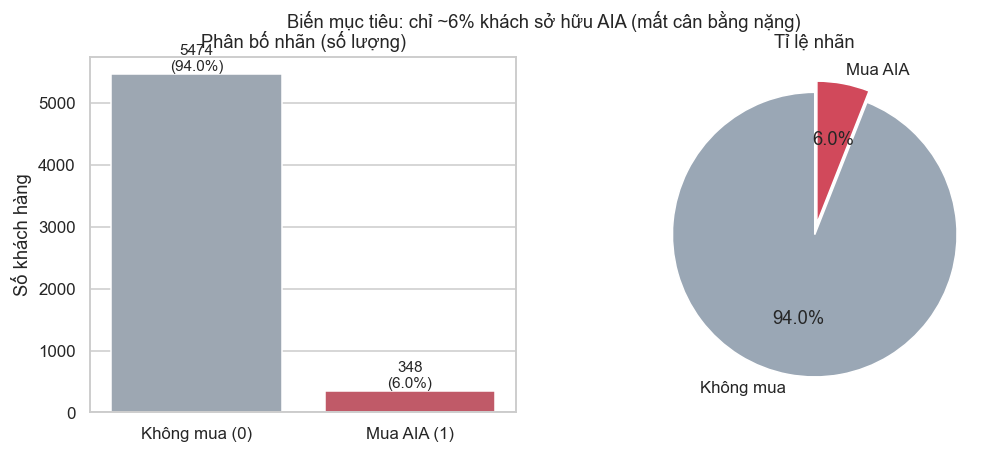

In [9]:
cnt = train[TARGET].value_counts().sort_index()
rate = train[TARGET].mean()
print("Số 0 (không mua):", int(cnt[0]), "| Số 1 (mua AIA):", int(cnt[1]))
print("Tỉ lệ dương: %.4f (%.2f%%)  | Mất cân bằng ~ 1:%.1f" % (rate, rate*100, cnt[0]/cnt[1]))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
sns.barplot(x=["Không mua (0)", "Mua AIA (1)"], y=cnt.values, ax=axes[0],
            palette=[PALETTE[0], PALETTE[1]])
for i, v in enumerate(cnt.values):
    axes[0].text(i, v + 50, f"{v}\n({v/len(train)*100:.1f}%)", ha="center", fontsize=10)
axes[0].set_title("Phân bố nhãn (số lượng)"); axes[0].set_ylabel("Số khách hàng")
axes[1].pie(cnt.values, labels=["Không mua", "Mua AIA"], autopct="%1.1f%%",
            colors=[PALETTE[0], PALETTE[1]], startangle=90, explode=(0, 0.08))
axes[1].set_title("Tỉ lệ nhãn")
plt.suptitle("Biến mục tiêu: chỉ ~6% khách sở hữu AIA (mất cân bằng nặng)", fontsize=12)
savefig("03_target_distribution"); plt.show()

## 4. Univariate — phân phối từng nhóm đặc trưng

Xem phân phối của: (a) nhóm nhân khẩu học chính (đã giải mã nhãn), (b) các biến tỉ lệ % theo vùng, (c) nhóm bảo hiểm khác (đóng phí & số HĐ) — vốn **rất nhiều giá trị 0** (zero-inflation).

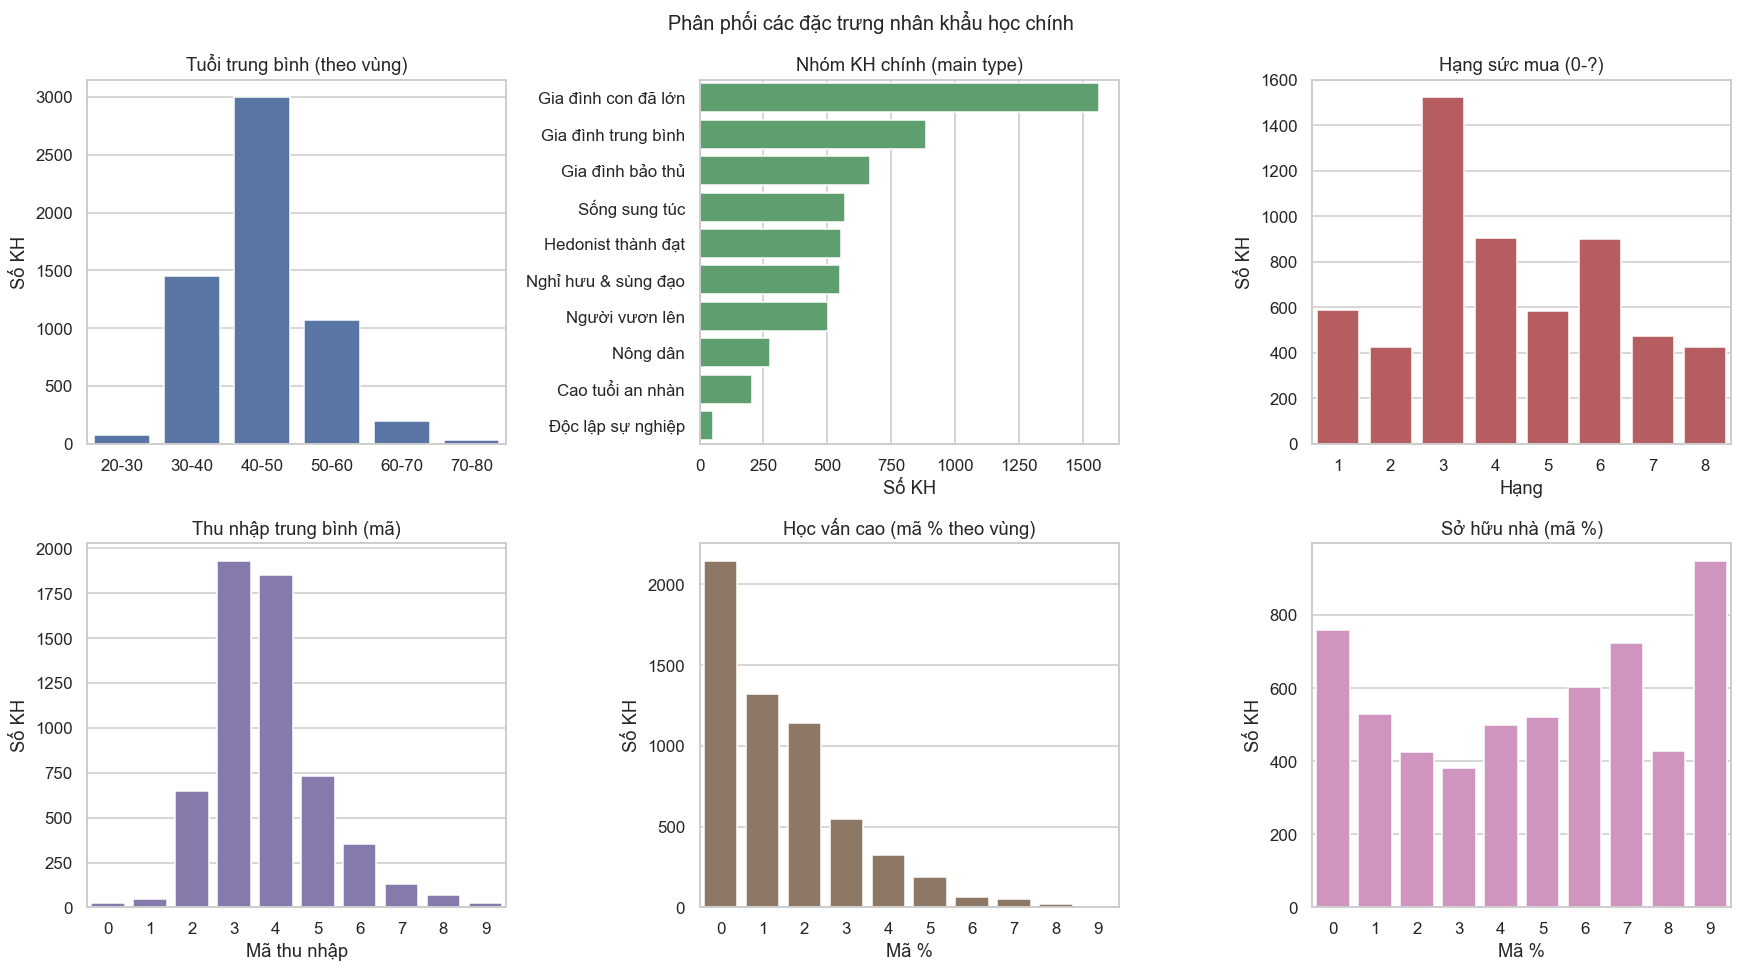

In [10]:
# (a) Nhân khẩu học chính: subtype, age, main type, học vấn, thu nhập, tầng lớp, ô tô, sức mua
fig, axes = plt.subplots(2, 3, figsize=(16, 9)); axes = axes.ravel()

# Tuổi (A2)
s = train["4"].map(A2).value_counts().reindex(list(A2.values()))
sns.barplot(x=s.index, y=s.values, ax=axes[0], color="#4c72b0"); axes[0].set_title("Tuổi trung bình (theo vùng)")
axes[0].set_xlabel(""); axes[0].set_ylabel("Số KH")

# Main type (A3)
s = train["5"].map(A3).value_counts()
sns.barplot(y=s.index, x=s.values, ax=axes[1], color="#55a868"); axes[1].set_title("Nhóm KH chính (main type)")
axes[1].set_xlabel("Số KH"); axes[1].set_ylabel("")

# Hạng sức mua
sns.countplot(x="43", data=train, ax=axes[2], color="#c44e52"); axes[2].set_title("Hạng sức mua (0-?)")
axes[2].set_xlabel("Hạng"); axes[2].set_ylabel("Số KH")

# Thu nhập trung bình
sns.countplot(x="42", data=train, ax=axes[3], color="#8172b3"); axes[3].set_title("Thu nhập trung bình (mã)")
axes[3].set_xlabel("Mã thu nhập"); axes[3].set_ylabel("Số KH")

# Học vấn cao (tỉ lệ %)
sns.countplot(x="16", data=train, ax=axes[4], color="#937860"); axes[4].set_title("Học vấn cao (mã % theo vùng)")
axes[4].set_xlabel("Mã %"); axes[4].set_ylabel("Số KH")

# Sở hữu nhà
sns.countplot(x="31", data=train, ax=axes[5], color="#da8bc3"); axes[5].set_title("Sở hữu nhà (mã %)")
axes[5].set_xlabel("Mã %"); axes[5].set_ylabel("Số KH")

plt.suptitle("Phân phối các đặc trưng nhân khẩu học chính", fontsize=13)
plt.tight_layout(); savefig("04a_socio_main"); plt.show()

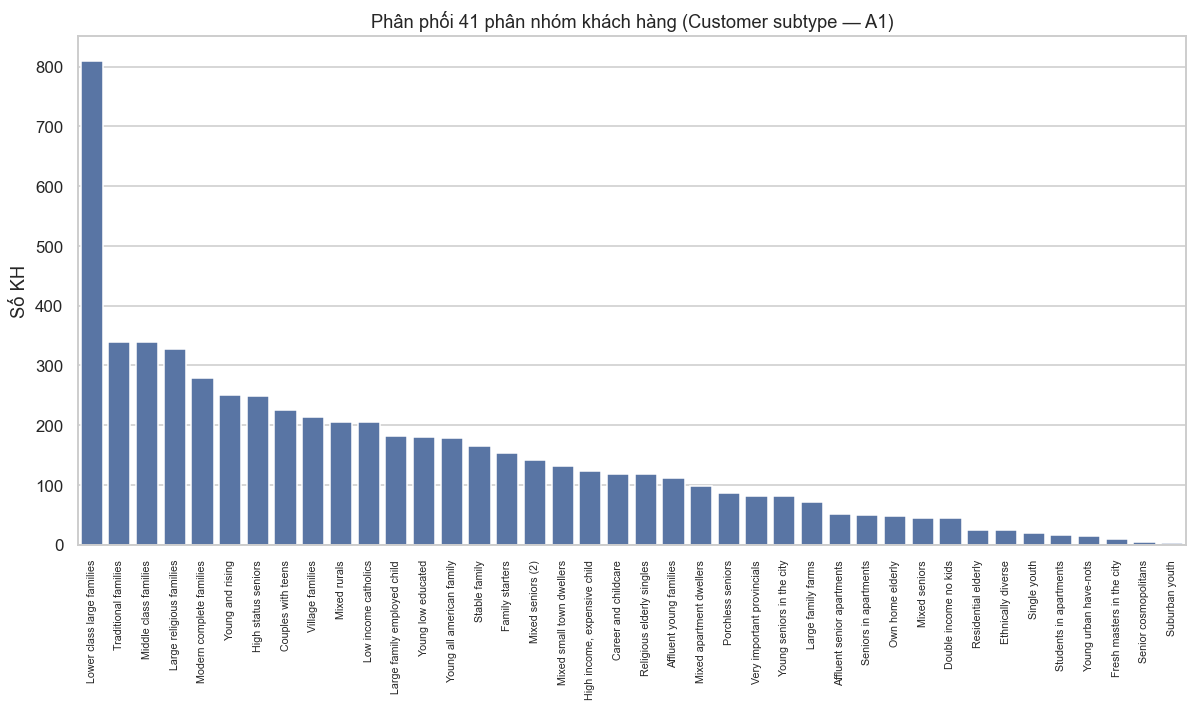

In [11]:
# Customer subtype (41 mức) — phân phối
s = train["1"].value_counts().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(x=[A1.get(i, i) for i in s.index], y=s.values, ax=ax, color="#4c72b0")
ax.set_title("Phân phối 41 phân nhóm khách hàng (Customer subtype — A1)")
ax.set_ylabel("Số KH"); ax.set_xlabel("")
plt.xticks(rotation=90, fontsize=7)
savefig("04b_subtype_distribution"); plt.show()

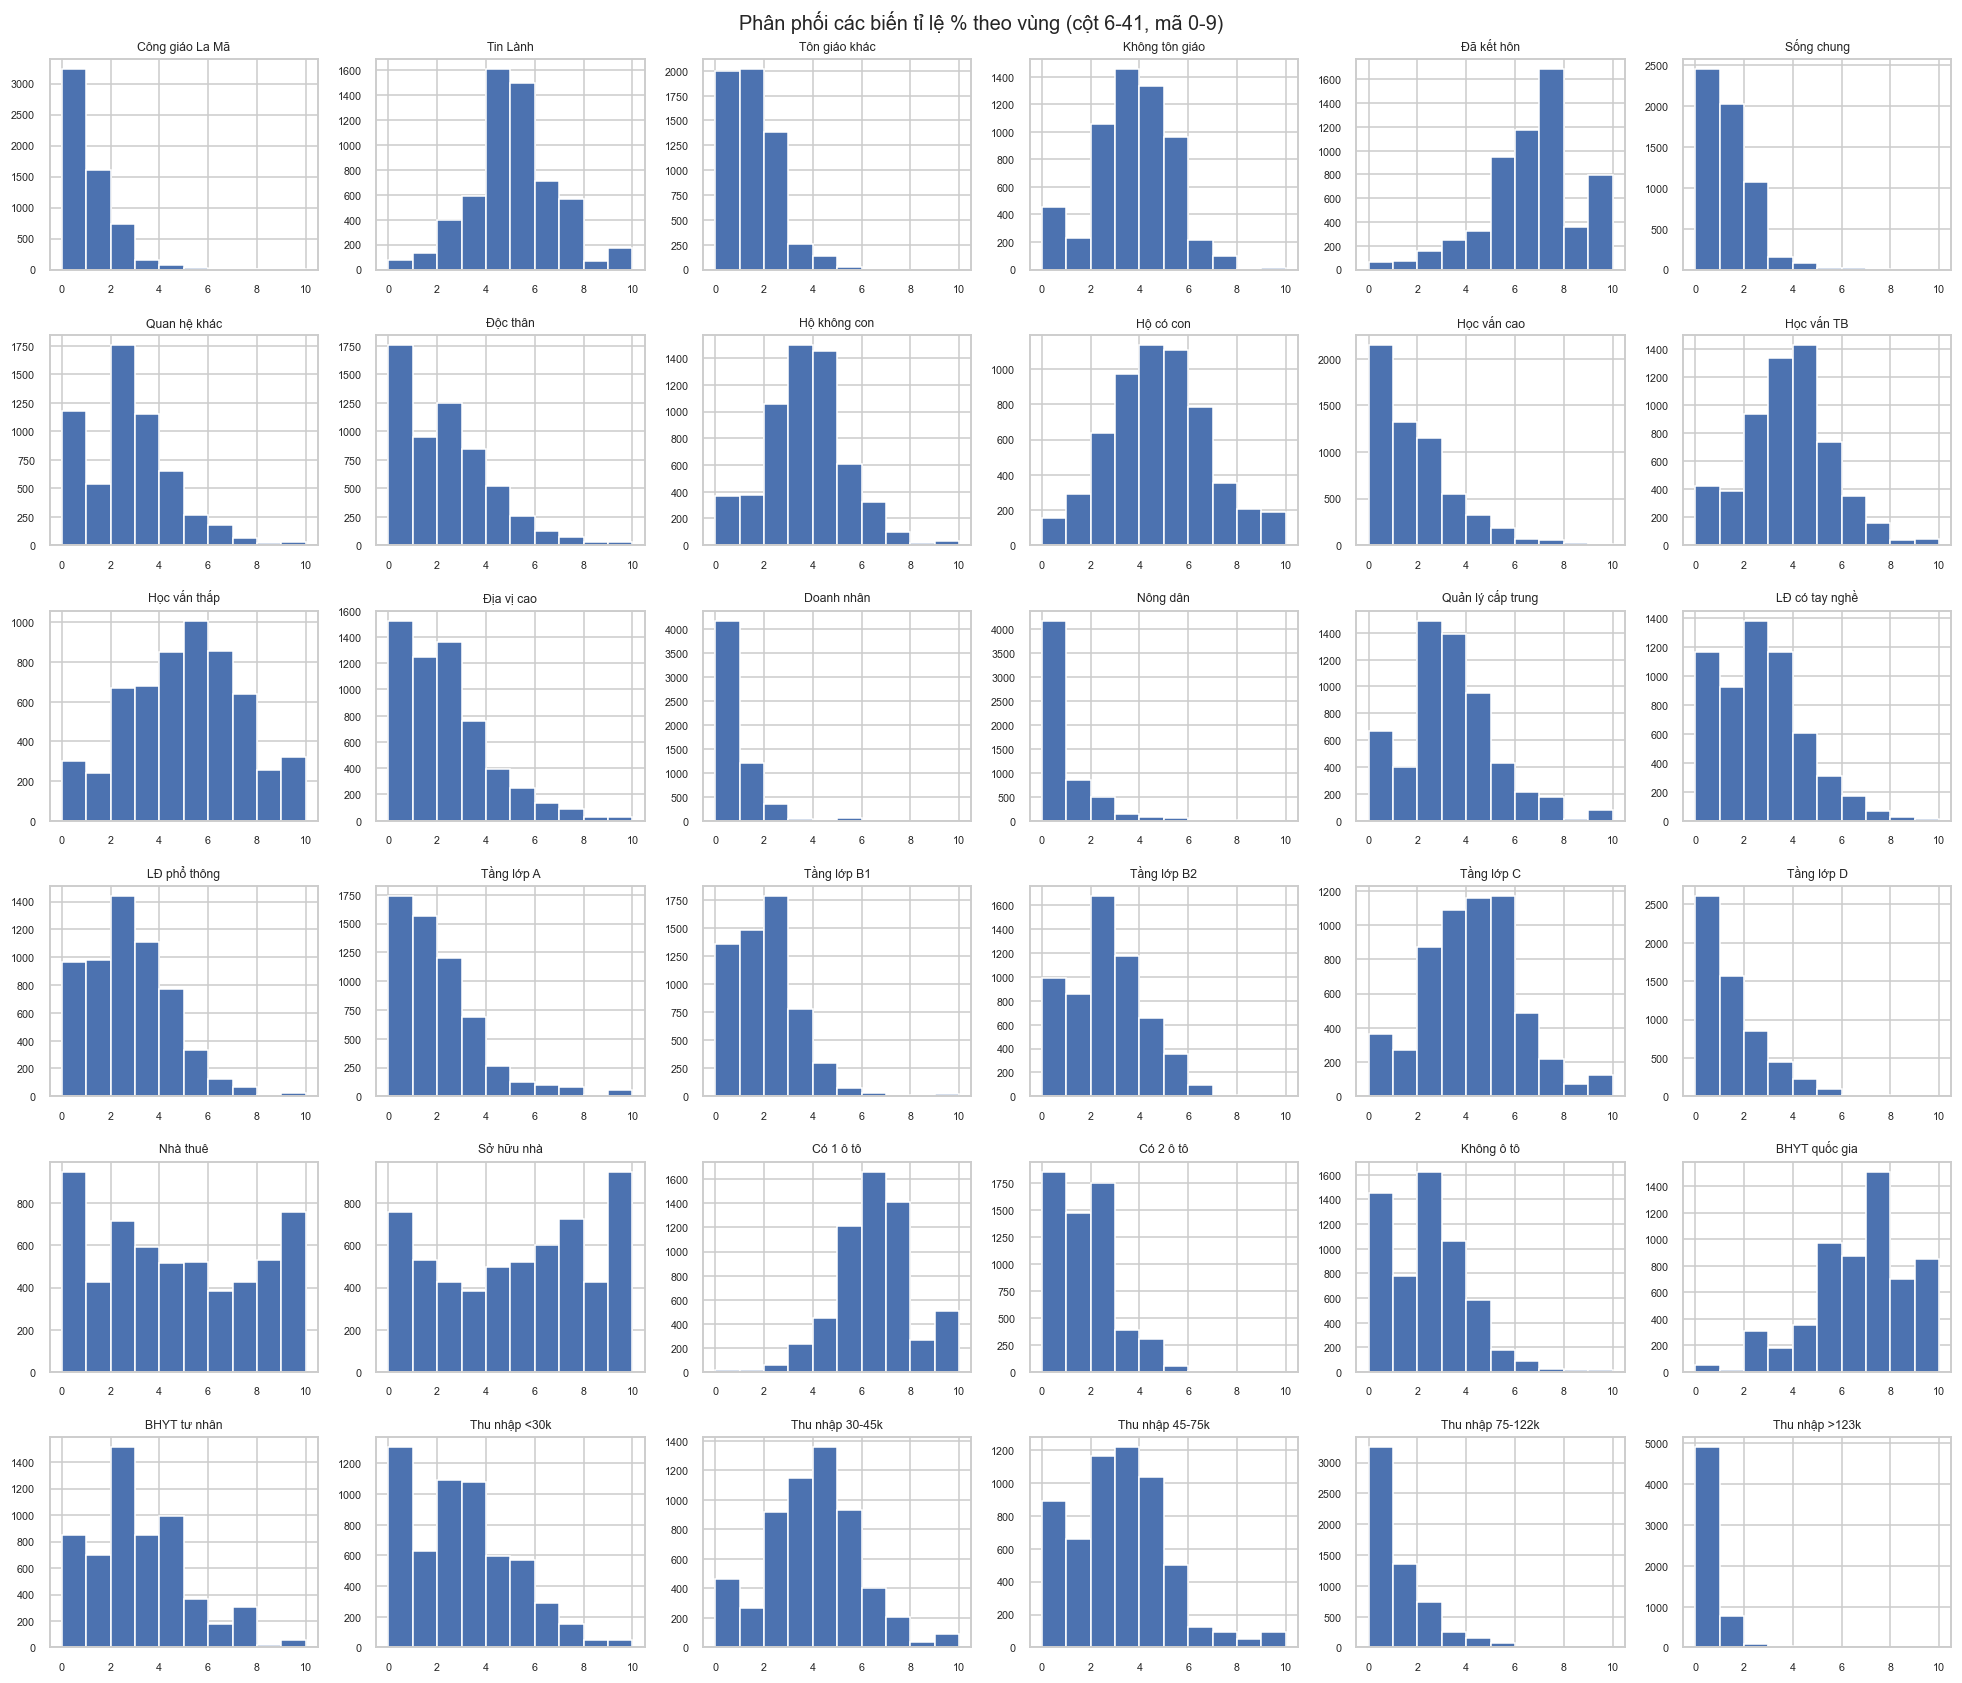

In [12]:
# (b) Lưới histogram cho các biến tỉ lệ % theo vùng (cột 6-41)
pct_cols = [str(i) for i in range(6, 42)]
n = len(pct_cols); ncol = 6; nrow = int(np.ceil(n/ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(18, 2.6*nrow)); axes = axes.ravel()
for i, c in enumerate(pct_cols):
    axes[i].hist(train[c], bins=range(0, 11), color="#4c72b0", edgecolor="white")
    axes[i].set_title(disp(c), fontsize=8); axes[i].tick_params(labelsize=7)
for j in range(i+1, len(axes)): axes[j].axis("off")
plt.suptitle("Phân phối các biến tỉ lệ % theo vùng (cột 6-41, mã 0-9)", fontsize=13)
plt.tight_layout(); savefig("04c_socio_pct_grid"); plt.show()

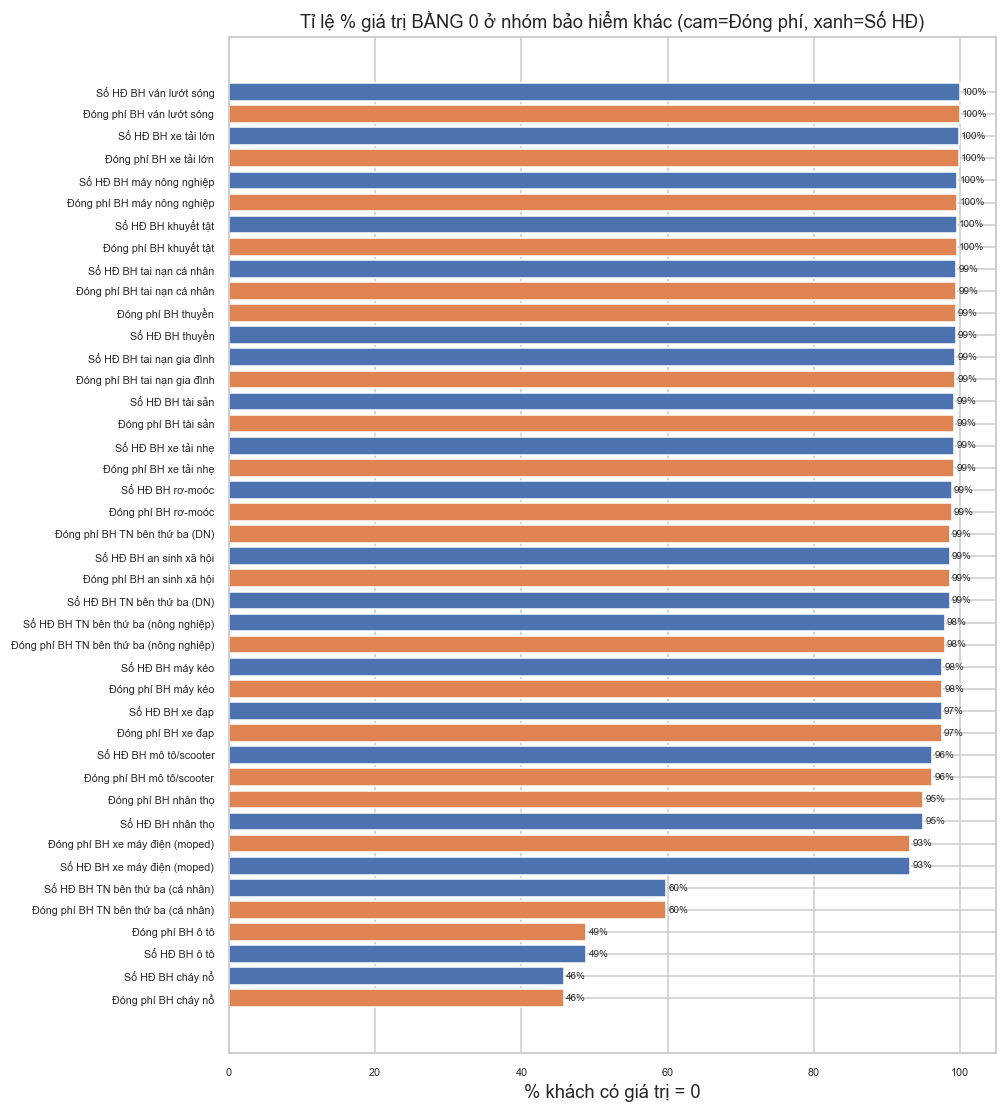

Phần lớn cột > 90%% giá trị 0 -> dữ liệu rất thưa (sparse).


In [13]:
# (c) Zero-inflation: % giá trị bằng 0 ở nhóm Đóng phí & Số HĐ
zero_pct = (train[CONTRIB + NUMBER] == 0).mean().sort_values()
labels = [disp(c) for c in zero_pct.index]
fig, ax = plt.subplots(figsize=(9, 12))
colors = ["#dd8452" if GROUP[c] == "Đóng phí (Contribution)" else "#4c72b0" for c in zero_pct.index]
ax.barh(labels, zero_pct.values*100, color=colors)
ax.set_title("Tỉ lệ % giá trị BẰNG 0 ở nhóm bảo hiểm khác (cam=Đóng phí, xanh=Số HĐ)")
ax.set_xlabel("% khách có giá trị = 0"); ax.tick_params(labelsize=7)
for i, v in enumerate(zero_pct.values*100):
    ax.text(v + 0.3, i, f"{v:.0f}%", va="center", fontsize=6.5)
savefig("04d_zero_inflation"); plt.show()
print("Phần lớn cột > 90%% giá trị 0 -> dữ liệu rất thưa (sparse).")

In [14]:
# Bảng thống kê mô tả toàn bộ 85 đặc trưng (xem nhanh)
desc = train[FEATURES].describe().T
desc.index = [disp(c) for c in desc.index]
desc.round(2)

,count,mean,std,min,25%,50%,75%,max
Phân nhóm KH (subtype),5822.0,24.25,12.85,1.0,10.0,30.0,35.0,41.0
Số nhà,5822.0,1.11,0.41,1.0,1.0,1.0,1.0,10.0
Quy mô hộ TB,5822.0,2.68,0.79,1.0,2.0,3.0,3.0,5.0
Tuổi TB,5822.0,2.99,0.81,1.0,2.0,3.0,3.0,6.0
Nhóm KH chính (main type),5822.0,5.77,2.86,1.0,3.0,7.0,8.0,10.0
...,...,...,...,...,...,...,...,...
Số HĐ BH ván lướt sóng,5822.0,0.00,0.02,0.0,0.0,0.0,0.0,1.0
Số HĐ BH thuyền,5822.0,0.01,0.08,0.0,0.0,0.0,0.0,2.0
Số HĐ BH xe đạp,5822.0,0.03,0.21,0.0,0.0,0.0,0.0,3.0
Số HĐ BH tài sản,5822.0,0.01,0.09,0.0,0.0,0.0,0.0,2.0


## 5. Bivariate — quan hệ đặc trưng ↔ target (trọng tâm)

Phần quan trọng nhất cho cả 2 nhiệm vụ: **đặc trưng nào phân biệt người mua AIA**.
- Tương quan Spearman của từng đặc trưng với nhãn.
- Chênh lệch trung bình chuẩn hoá (standardized mean difference) giữa nhóm mua / không mua.
- **Lift theo mức** = P(mua | mức) / tỉ lệ nền (~6%) cho các đặc trưng mạnh nhất.

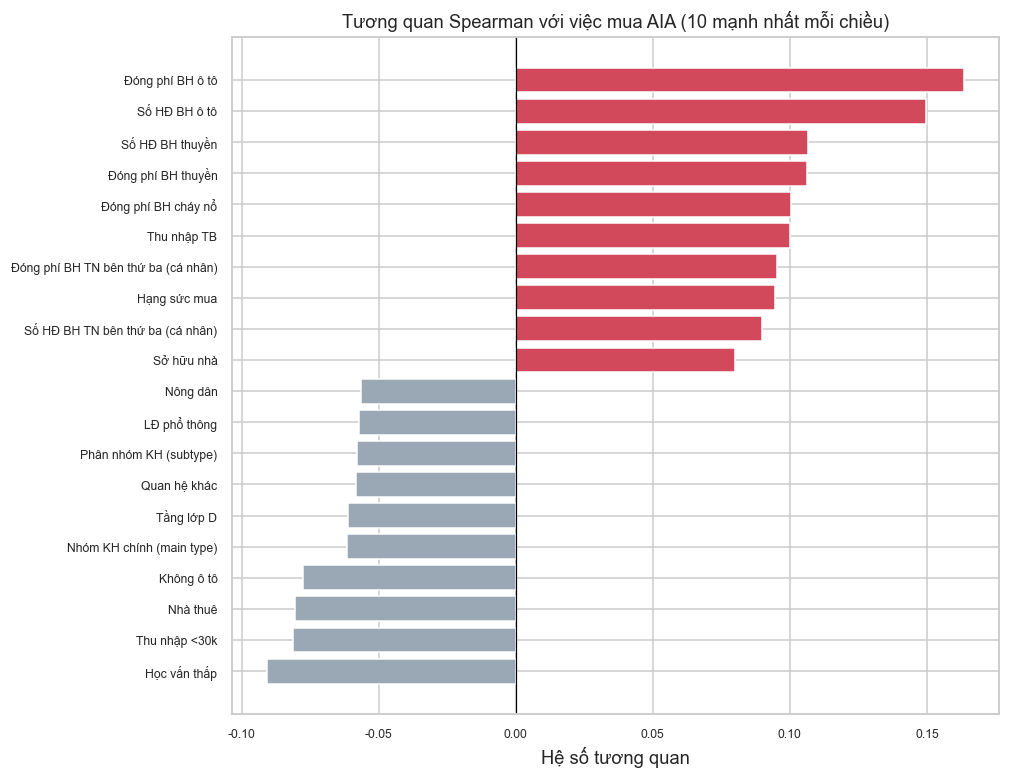

Top đặc trưng |tương quan| cao nhất:
  Đóng phí BH ô tô                               rho=+0.164
  Số HĐ BH ô tô                                  rho=+0.149
  Số HĐ BH thuyền                                rho=+0.106
  Đóng phí BH thuyền                             rho=+0.106
  Đóng phí BH cháy nổ                            rho=+0.101
  Thu nhập TB                                    rho=+0.100
  Đóng phí BH TN bên thứ ba (cá nhân)            rho=+0.095
  Hạng sức mua                                   rho=+0.095
  Học vấn thấp                                   rho=-0.091
  Số HĐ BH TN bên thứ ba (cá nhân)               rho=+0.090


In [15]:
# Tương quan Spearman với target -> xếp hạng đặc trưng
from scipy.stats import spearmanr
corr_t = train[FEATURES].apply(lambda s: spearmanr(s, train[TARGET]).statistic)
corr_t = corr_t.sort_values()
top_feats = corr_t.abs().sort_values(ascending=False).head(15).index.tolist()

show = pd.concat([corr_t.head(10), corr_t.tail(10)])
fig, ax = plt.subplots(figsize=(9, 8))
colors = ["#d1495b" if v > 0 else "#9aa7b5" for v in show.values]
ax.barh([disp(c) for c in show.index], show.values, color=colors)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Tương quan Spearman với việc mua AIA (10 mạnh nhất mỗi chiều)")
ax.set_xlabel("Hệ số tương quan"); ax.tick_params(labelsize=8)
savefig("05a_corr_with_target"); plt.show()
print("Top đặc trưng |tương quan| cao nhất:")
for c in top_feats[:10]:
    print(f"  {disp(c):45s}  rho={corr_t[c]:+.3f}")

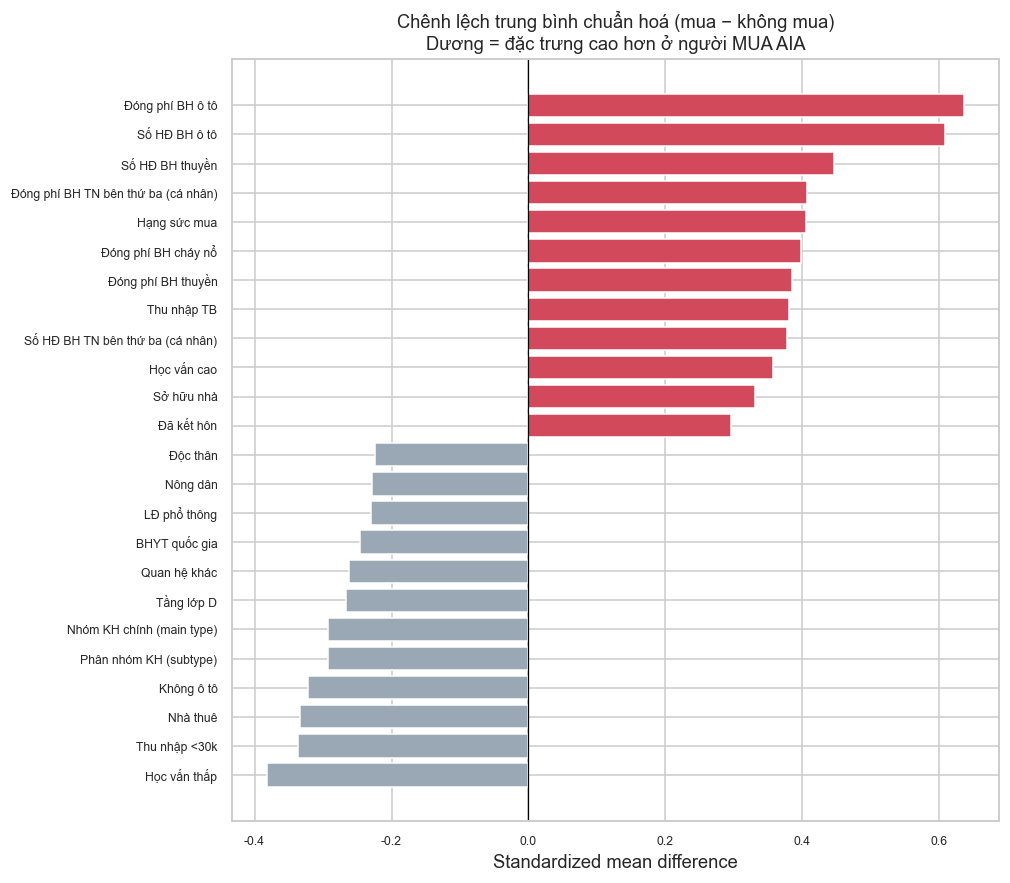

In [16]:
# Chênh lệch trung bình chuẩn hoá giữa nhóm mua (1) và không mua (0)
pos = train[train[TARGET] == 1][FEATURES].mean()
neg = train[train[TARGET] == 0][FEATURES].mean()
sd  = train[FEATURES].std().replace(0, np.nan)
smd = ((pos - neg) / sd).sort_values()
sel = pd.concat([smd.head(12), smd.tail(12)])
fig, ax = plt.subplots(figsize=(9, 9))
ax.barh([disp(c) for c in sel.index], sel.values,
        color=["#d1495b" if v > 0 else "#9aa7b5" for v in sel.values])
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Chênh lệch trung bình chuẩn hoá (mua − không mua)\nDương = đặc trưng cao hơn ở người MUA AIA")
ax.set_xlabel("Standardized mean difference"); ax.tick_params(labelsize=8)
savefig("05b_std_mean_diff"); plt.show()

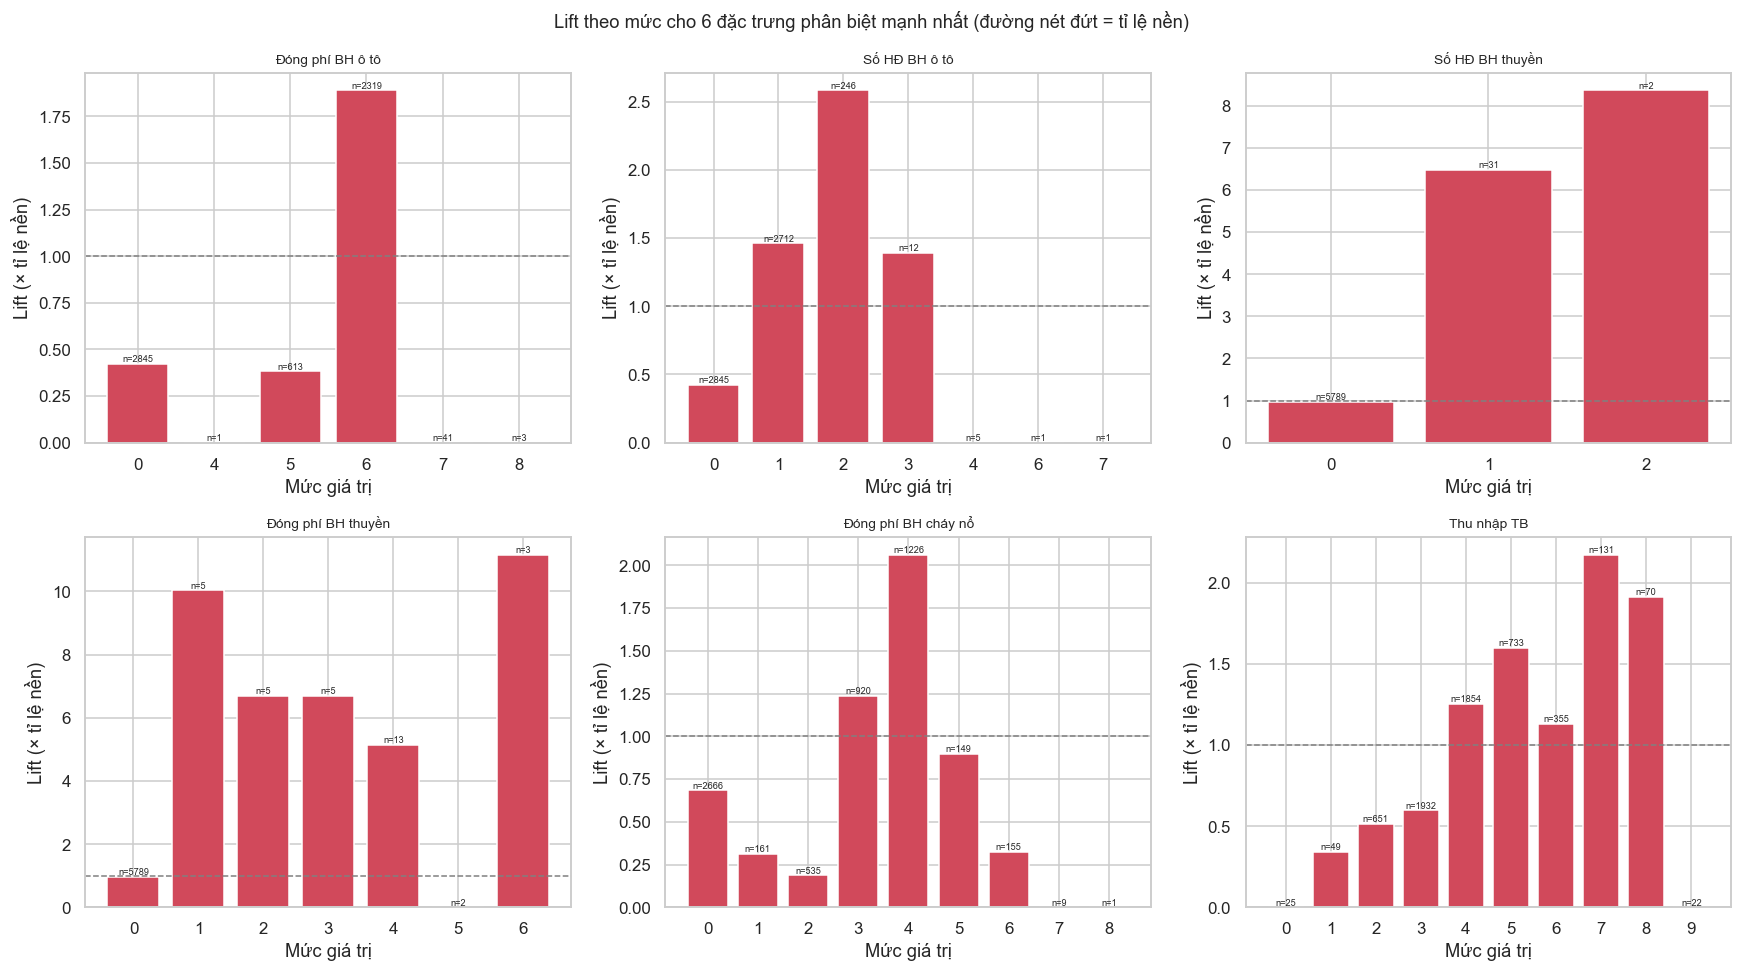

In [17]:
# Hàm lift theo mức + biểu đồ lưới cho các đặc trưng mạnh nhất
base_rate = train[TARGET].mean()
def lift_table(col):
    g = train.groupby(col)[TARGET].agg(ty_le="mean", so_kh="count")
    g["lift"] = g["ty_le"] / base_rate
    return g

feat6 = top_feats[:6]
fig, axes = plt.subplots(2, 3, figsize=(16, 9)); axes = axes.ravel()
for i, c in enumerate(feat6):
    g = lift_table(c)
    bars = axes[i].bar(g.index.astype(str), g["lift"], color="#d1495b")
    axes[i].axhline(1, color="gray", ls="--", lw=1)
    axes[i].set_title(disp(c), fontsize=9)
    axes[i].set_ylabel("Lift (× tỉ lệ nền)"); axes[i].set_xlabel("Mức giá trị")
    for b, n_ in zip(bars, g["so_kh"]):
        axes[i].text(b.get_x()+b.get_width()/2, b.get_height(), f"n={n_}",
                     ha="center", va="bottom", fontsize=6)
plt.suptitle("Lift theo mức cho 6 đặc trưng phân biệt mạnh nhất (đường nét đứt = tỉ lệ nền)", fontsize=12)
plt.tight_layout(); savefig("05c_lift_top_features"); plt.show()

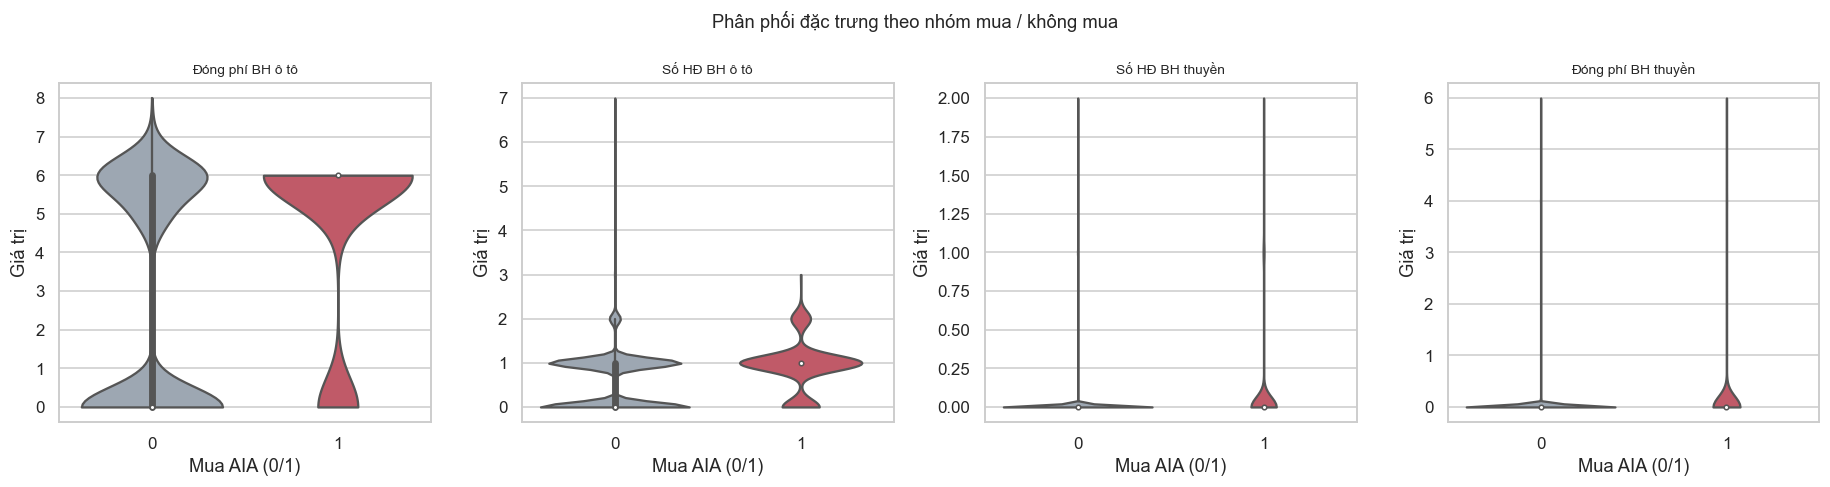

In [18]:
# Box/violin cho vài đặc trưng ordinal nổi bật theo nhãn
feat_box = top_feats[:4]
fig, axes = plt.subplots(1, len(feat_box), figsize=(4.2*len(feat_box), 4.5))
for i, c in enumerate(feat_box):
    sns.violinplot(x=TARGET, y=c, data=train, ax=axes[i], palette=[PALETTE[0], PALETTE[1]], cut=0)
    axes[i].set_title(disp(c), fontsize=9)
    axes[i].set_xlabel("Mua AIA (0/1)"); axes[i].set_ylabel("Giá trị")
plt.suptitle("Phân phối đặc trưng theo nhóm mua / không mua", fontsize=12)
plt.tight_layout(); savefig("05d_violin_by_target"); plt.show()

## 6. Multivariate & tương quan

Heatmap tương quan, phát hiện **đa cộng tuyến** và **cặp Đóng phí ↔ Số HĐ** (44↔65, …) gần như trùng nhau, gom nhóm đặc trưng tương quan, và chiếu 2D (PCA, t-SNE) tô màu theo nhãn.

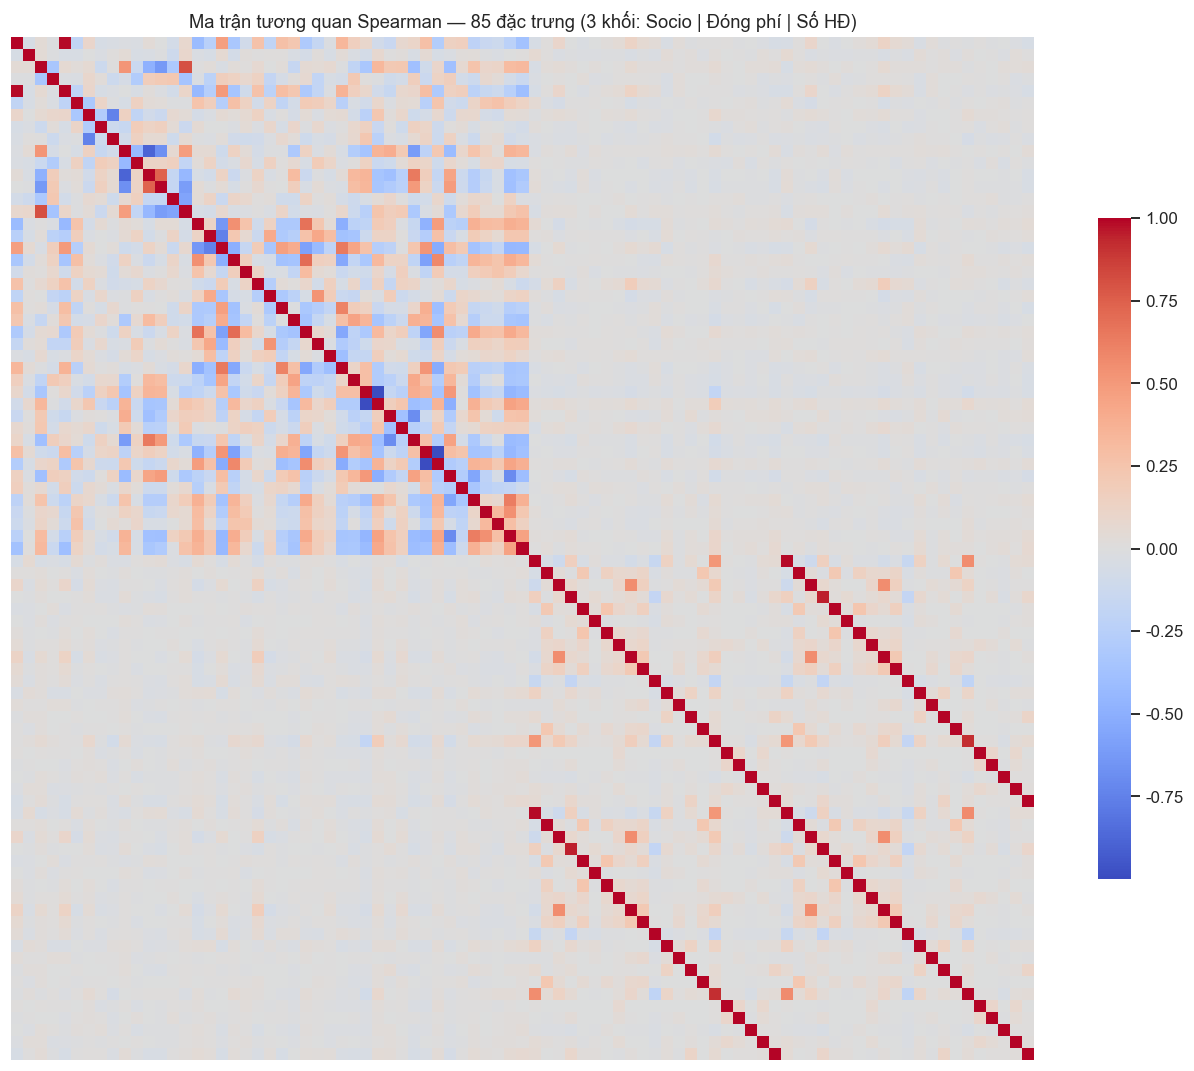

In [19]:
# Heatmap Spearman toàn bộ 85 đặc trưng
corr = train[FEATURES].corr(method="spearman")
fig, ax = plt.subplots(figsize=(15, 13))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": .6},
            xticklabels=False, yticklabels=False, ax=ax)
ax.set_title("Ma trận tương quan Spearman — 85 đặc trưng (3 khối: Socio | Đóng phí | Số HĐ)")
savefig("06a_corr_heatmap_full"); plt.show()

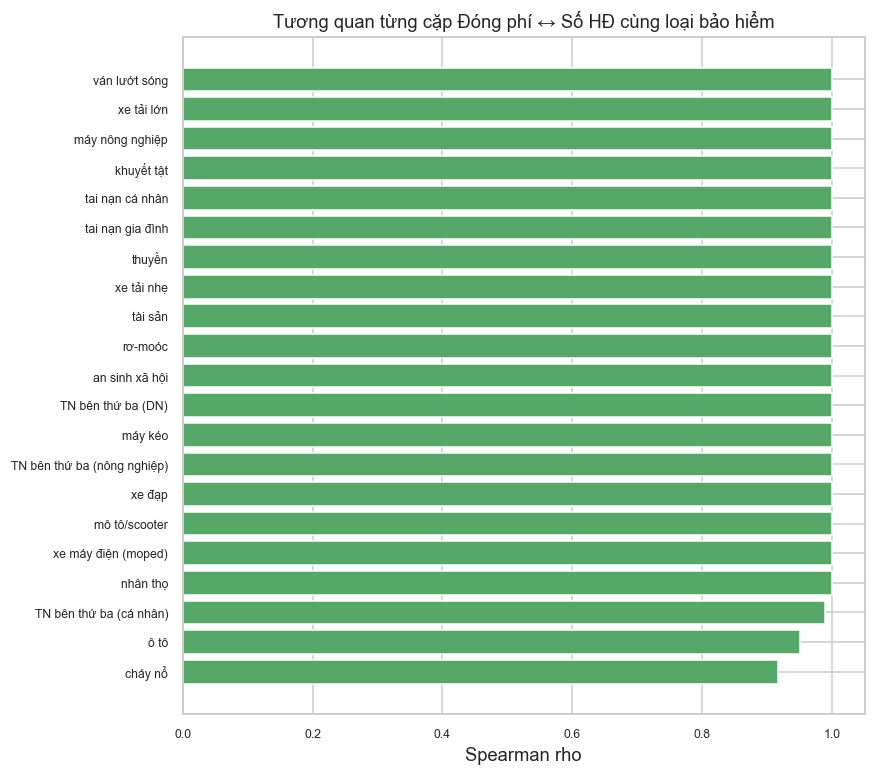

rho trung bình của các cặp: 0.993 -> Đóng phí và Số HĐ gần như dư thừa nhau.


In [20]:
# Xác nhận cặp Đóng phí (44+i) <-> Số HĐ (65+i) tương quan rất cao
pair = pd.DataFrame({
    "Loại bảo hiểm": INS_TYPES,
    "rho(Đóng phí, Số HĐ)": [spearmanr(train[str(44+i)], train[str(65+i)]).statistic for i in range(21)],
}).sort_values("rho(Đóng phí, Số HĐ)", ascending=False)
fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(pair["Loại bảo hiểm"], pair["rho(Đóng phí, Số HĐ)"], color="#55a868")
ax.set_title("Tương quan từng cặp Đóng phí ↔ Số HĐ cùng loại bảo hiểm")
ax.set_xlabel("Spearman rho"); ax.invert_yaxis(); ax.tick_params(labelsize=8)
savefig("06b_contrib_number_pairs"); plt.show()
print("rho trung bình của các cặp: %.3f -> Đóng phí và Số HĐ gần như dư thừa nhau." % pair["rho(Đóng phí, Số HĐ)"].mean())

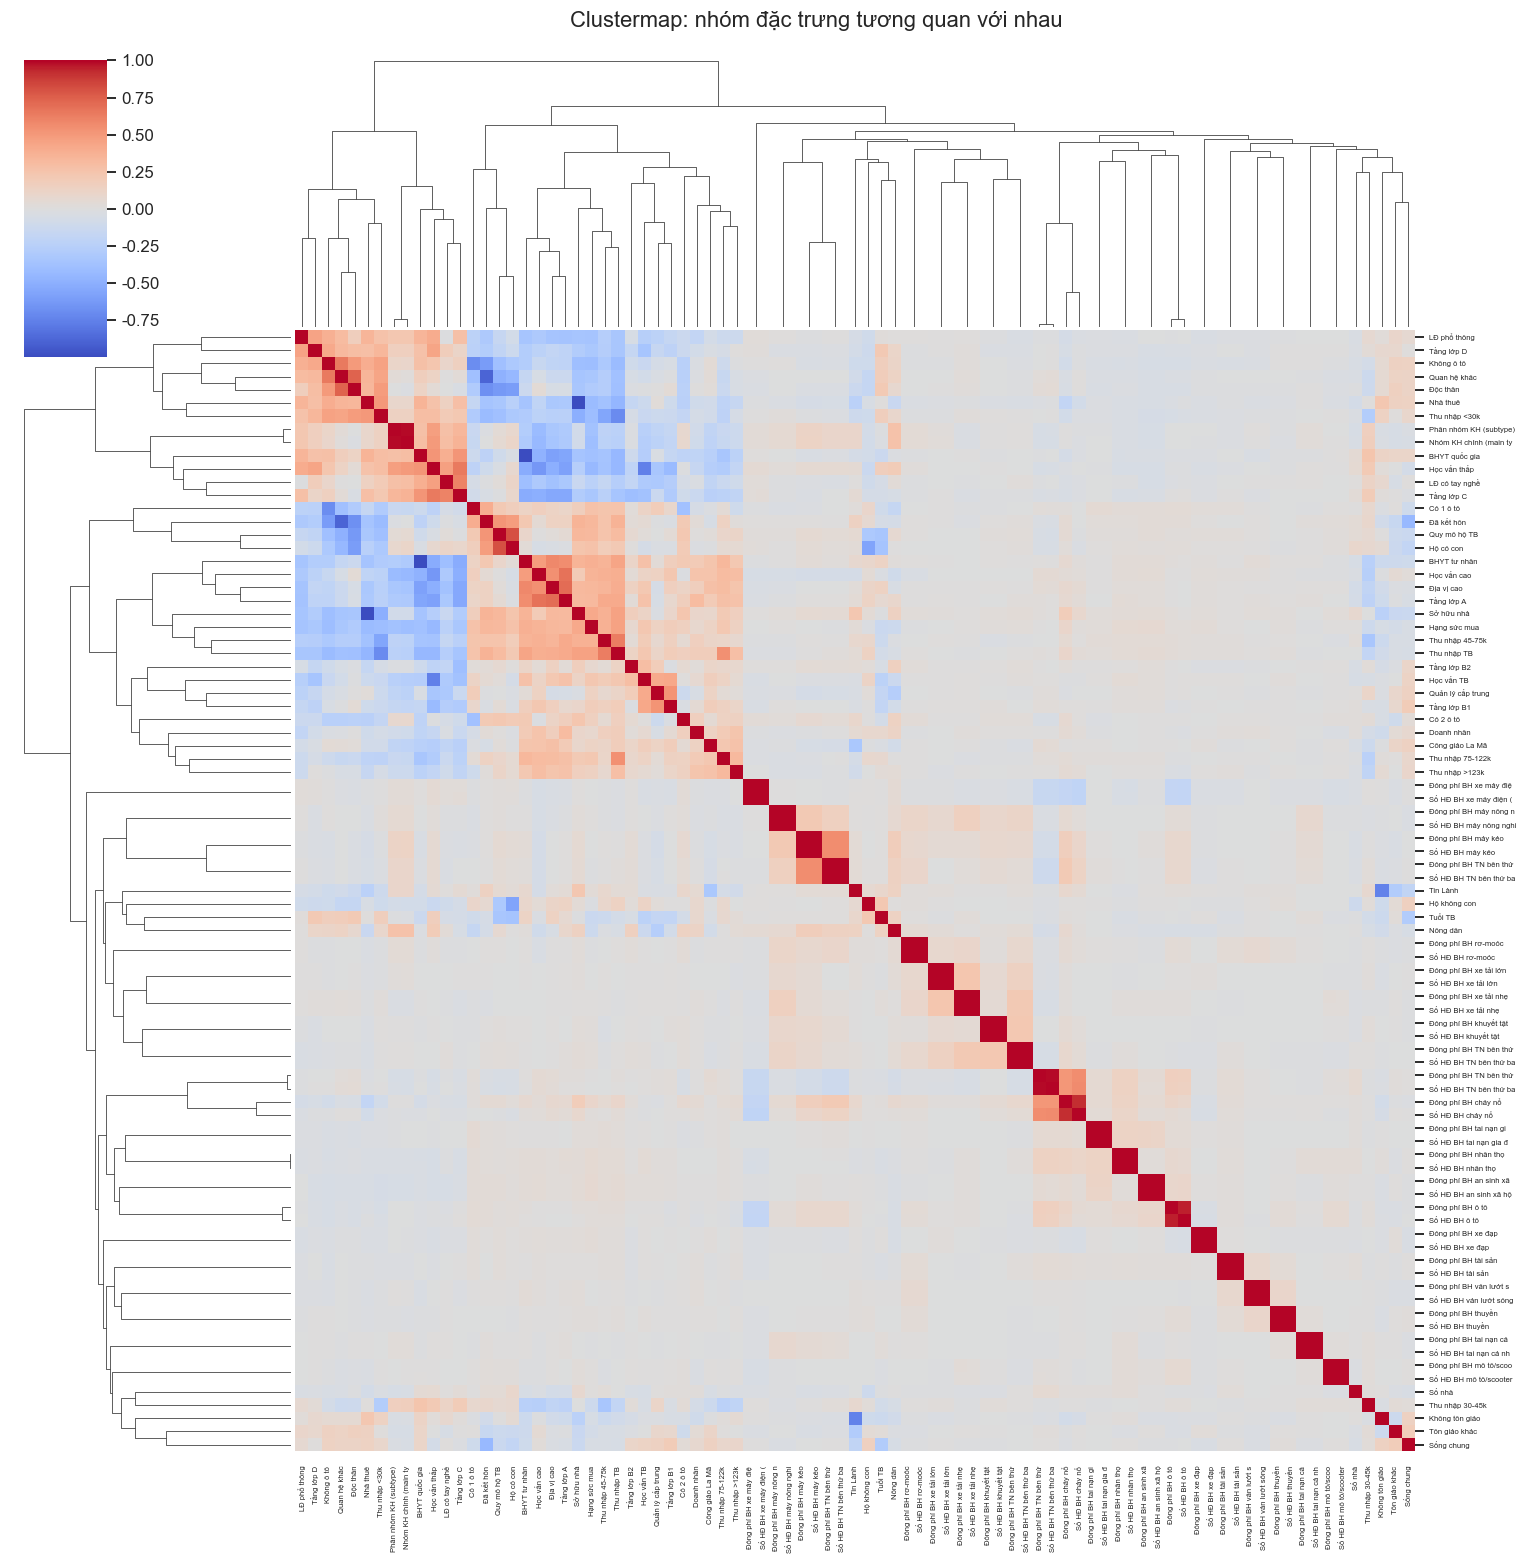

In [21]:
# Clustermap gom nhóm đặc trưng tương quan (dùng nhãn rút gọn)
short = {c: disp(c)[:22] for c in FEATURES}
cm = train[FEATURES].corr(method="spearman").rename(index=short, columns=short)
g = sns.clustermap(cm, cmap="coolwarm", center=0, figsize=(15, 15),
                   xticklabels=True, yticklabels=True)
g.ax_heatmap.tick_params(labelsize=5)
g.fig.suptitle("Clustermap: nhóm đặc trưng tương quan với nhau", y=1.01)
g.savefig(FIG_DIR / "06c_clustermap.png", dpi=150, bbox_inches="tight"); plt.show()

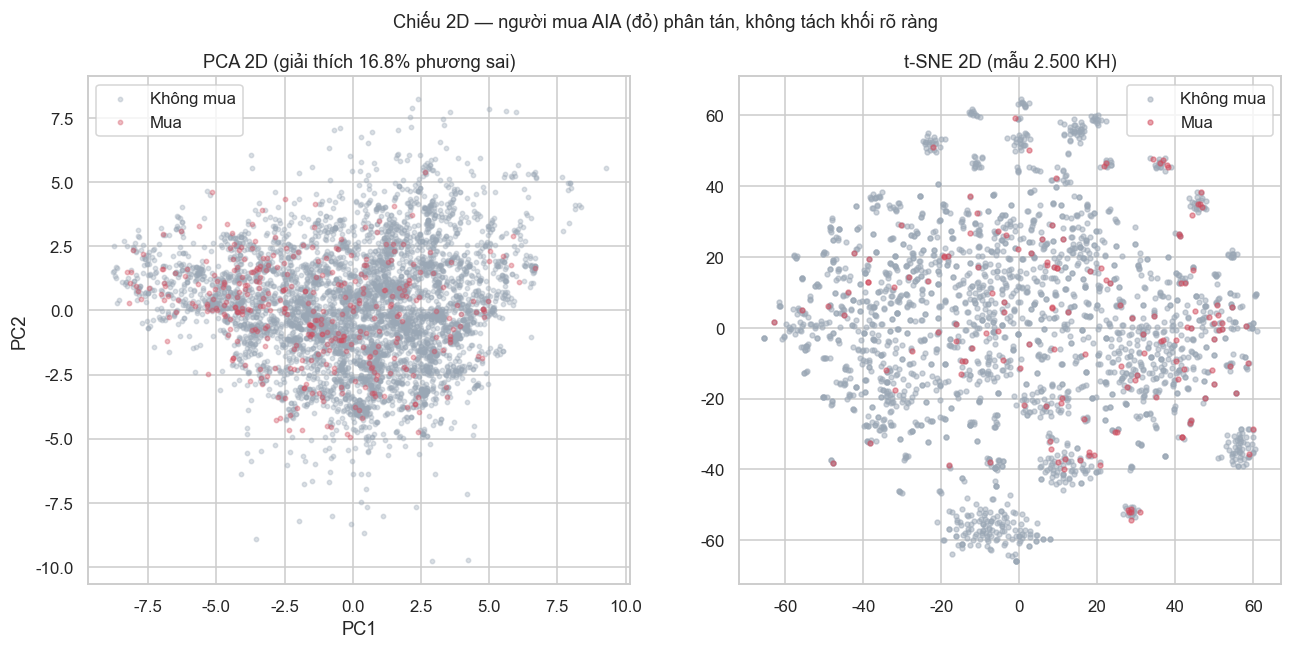

In [22]:
# Chiếu 2D: PCA (toàn bộ) + t-SNE (mẫu) tô màu theo nhãn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

Xs = StandardScaler().fit_transform(train[FEATURES])
pca = PCA(n_components=2, random_state=0).fit(Xs)
P = pca.transform(Xs)

rng = np.random.RandomState(0)
idx = rng.choice(len(train), size=min(2500, len(train)), replace=False)
T = TSNE(n_components=2, perplexity=30, init="pca", random_state=0).fit_transform(Xs[idx])
yt = train[TARGET].values[idx]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for lab, col in PALETTE.items():
    m = train[TARGET].values == lab
    axes[0].scatter(P[m, 0], P[m, 1], s=8, alpha=.35, color=col, label=("Mua" if lab else "Không mua"))
axes[0].set_title(f"PCA 2D (giải thích {pca.explained_variance_ratio_.sum()*100:.1f}% phương sai)")
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2"); axes[0].legend()
for lab, col in PALETTE.items():
    m = yt == lab
    axes[1].scatter(T[m, 0], T[m, 1], s=10, alpha=.5, color=col, label=("Mua" if lab else "Không mua"))
axes[1].set_title("t-SNE 2D (mẫu 2.500 KH)"); axes[1].legend()
plt.suptitle("Chiếu 2D — người mua AIA (đỏ) phân tán, không tách khối rõ ràng", fontsize=12)
savefig("06d_pca_tsne"); plt.show()

## 7. Phân khúc khách hàng (actionable cho giám đốc)

Trả lời trực tiếp câu hỏi *"nên nhắm nhóm khách nào?"* bằng **tỉ lệ mua AIA theo phân khúc** và **bản đồ nhiệt** giao thoa các chiều nhân khẩu học.

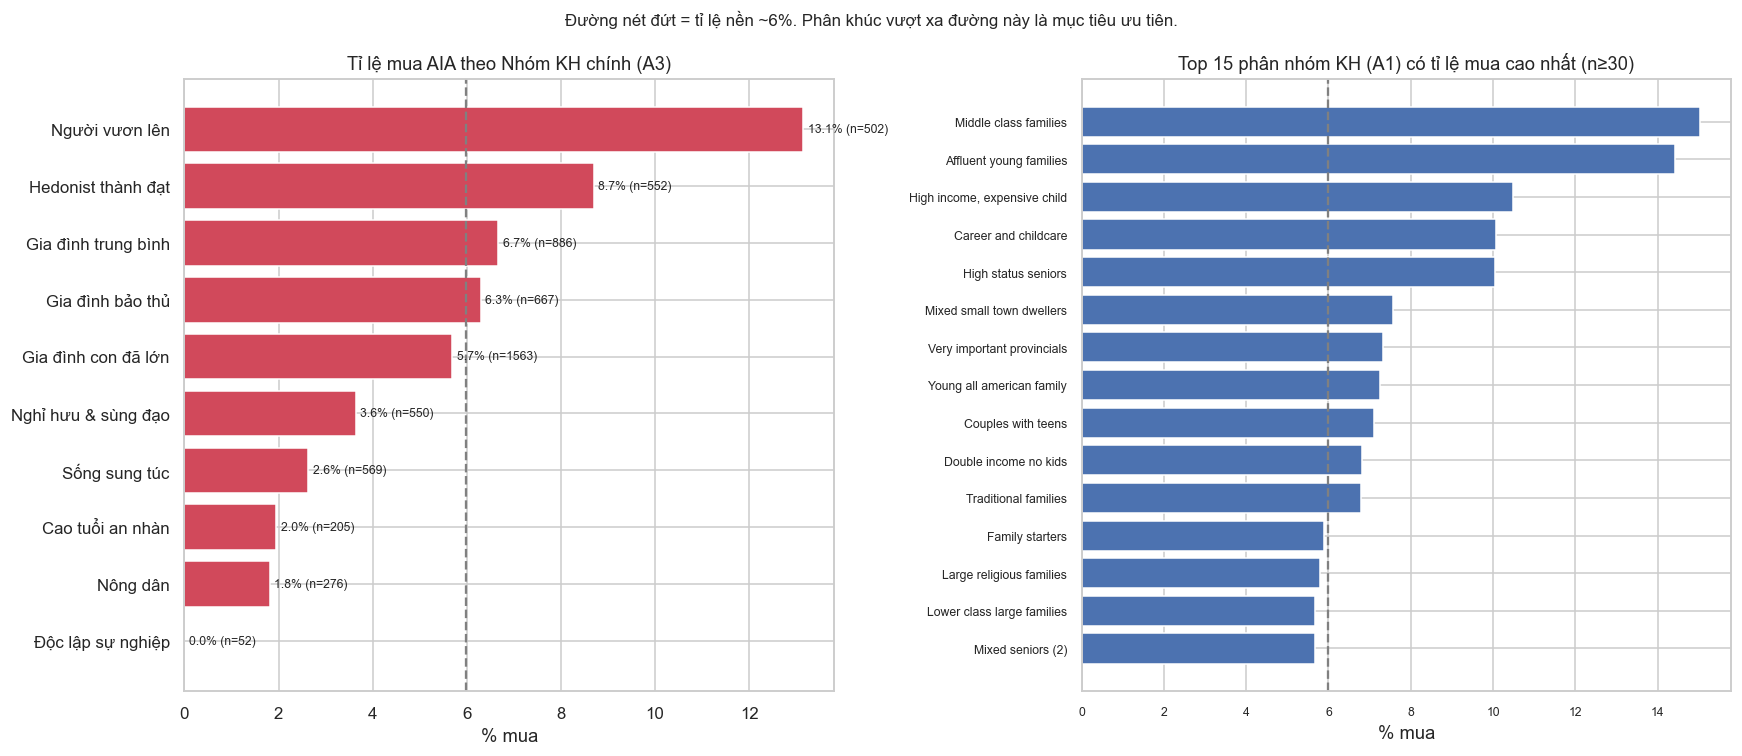

In [23]:
# Tỉ lệ mua theo main type (A3) và subtype (A1), kèm cỡ mẫu
def rate_by(col, mapping, min_n=20):
    g = train.groupby(col)[TARGET].agg(ty_le="mean", n="count")
    g = g[g["n"] >= min_n].sort_values("ty_le", ascending=False)
    g.index = [mapping.get(i, i) for i in g.index]
    return g

mt = rate_by("5", A3, min_n=0)
st = rate_by("1", A1, min_n=30)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
axes[0].barh(mt.index, mt["ty_le"]*100, color="#d1495b"); axes[0].invert_yaxis()
axes[0].axvline(base_rate*100, color="gray", ls="--"); axes[0].set_title("Tỉ lệ mua AIA theo Nhóm KH chính (A3)")
axes[0].set_xlabel("% mua")
for i, (v, n_) in enumerate(zip(mt["ty_le"]*100, mt["n"])):
    axes[0].text(v+0.1, i, f"{v:.1f}% (n={n_})", va="center", fontsize=8)

st15 = st.head(15)
axes[1].barh(st15.index, st15["ty_le"]*100, color="#4c72b0"); axes[1].invert_yaxis()
axes[1].axvline(base_rate*100, color="gray", ls="--")
axes[1].set_title("Top 15 phân nhóm KH (A1) có tỉ lệ mua cao nhất (n≥30)")
axes[1].set_xlabel("% mua"); axes[1].tick_params(labelsize=8)
plt.suptitle("Đường nét đứt = tỉ lệ nền ~6%. Phân khúc vượt xa đường này là mục tiêu ưu tiên.", fontsize=11)
plt.tight_layout(); savefig("07a_rate_by_segment"); plt.show()

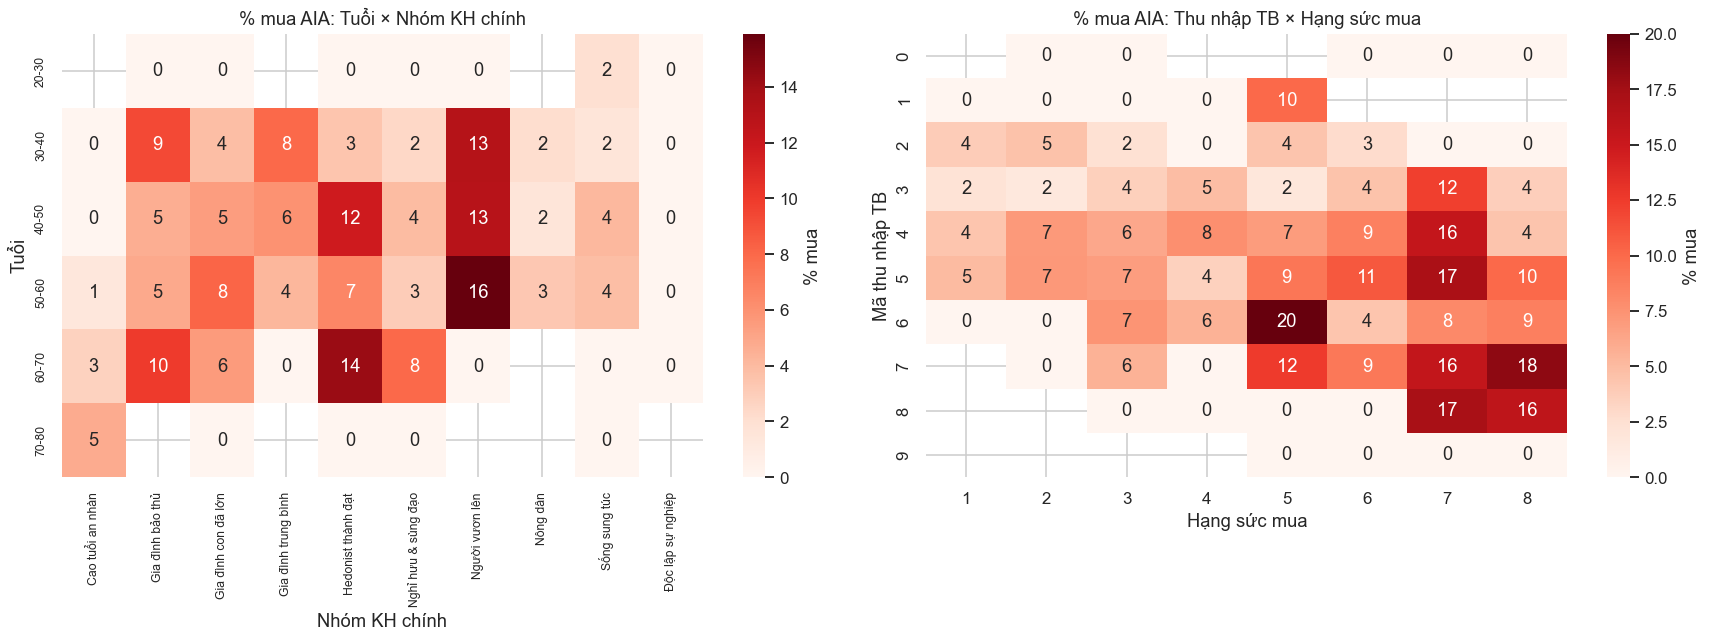

In [24]:
# Bản đồ nhiệt tỉ lệ mua theo 2 chiều: Tuổi × Main type ; Thu nhập × Sức mua
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
p1 = train.pivot_table(index=train["4"].map(A2), columns=train["5"].map(A3),
                       values=TARGET, aggfunc="mean")
sns.heatmap(p1*100, annot=True, fmt=".0f", cmap="Reds", ax=axes[0], cbar_kws={"label": "% mua"})
axes[0].set_title("% mua AIA: Tuổi × Nhóm KH chính"); axes[0].set_xlabel("Nhóm KH chính"); axes[0].set_ylabel("Tuổi")
axes[0].tick_params(labelsize=8)

p2 = train.pivot_table(index="42", columns="43", values=TARGET, aggfunc="mean")
sns.heatmap(p2*100, annot=True, fmt=".0f", cmap="Reds", ax=axes[1], cbar_kws={"label": "% mua"})
axes[1].set_title("% mua AIA: Thu nhập TB × Hạng sức mua")
axes[1].set_xlabel("Hạng sức mua"); axes[1].set_ylabel("Mã thu nhập TB")
plt.tight_layout(); savefig("07b_segment_heatmaps"); plt.show()

## 8. Tín hiệu dự đoán (bắc cầu sang nhiệm vụ mô hình)

Lượng hoá sức mạnh dự đoán: **mutual information**, bảng **lift đơn biến**, một vài **baseline** (Logistic Regression, Random Forest, Gradient Boosting) với **ROC-AUC** và **đường lift/gains mô phỏng việc lấy top 20% (~800/4000)**, cùng **feature importance / permutation importance** và **SHAP (tùy chọn)**.

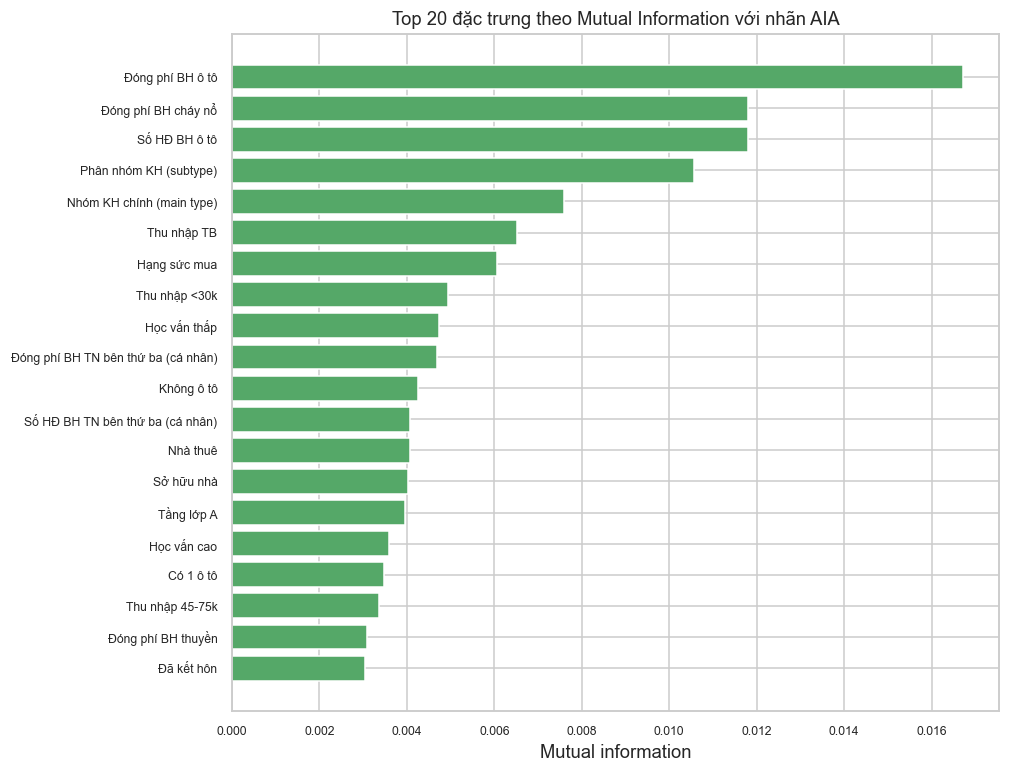

In [25]:
from sklearn.feature_selection import mutual_info_classif
mi = pd.Series(
    mutual_info_classif(train[FEATURES], train[TARGET], discrete_features=True, random_state=0),
    index=FEATURES).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 8))
top_mi = mi.head(20)
ax.barh([disp(c) for c in top_mi.index][::-1], top_mi.values[::-1], color="#55a868")
ax.set_title("Top 20 đặc trưng theo Mutual Information với nhãn AIA")
ax.set_xlabel("Mutual information"); ax.tick_params(labelsize=8)
savefig("08a_mutual_information"); plt.show()

In [26]:
# Bảng lift đơn biến tổng hợp: mức tốt nhất của mỗi đặc trưng top
rows = []
for c in mi.head(12).index:
    g = lift_table(c)
    g = g[g["so_kh"] >= 30]
    if len(g) == 0:
        continue
    best = g.sort_values("lift", ascending=False).iloc[0]
    rows.append({"Đặc trưng": disp(c), "Mức tốt nhất": g["lift"].idxmax(),
                 "Tỉ lệ mua": f"{best['ty_le']*100:.1f}%", "Lift": round(best["lift"], 2),
                 "n": int(best["so_kh"])})
pd.DataFrame(rows).sort_values("Lift", ascending=False).reset_index(drop=True)

,Đặc trưng,Mức tốt nhất,Tỉ lệ mua,Lift,n
0,Số HĐ BH ô tô,2,15.4%,2.58,246
1,Phân nhóm KH (subtype),8,15.0%,2.52,339
2,Hạng sức mua,7,14.1%,2.36,474
3,Nhóm KH chính (main type),2,13.1%,2.20,502
4,Thu nhập TB,7,13.0%,2.17,131
5,Đóng phí BH cháy nổ,4,12.3%,2.06,1226
6,Đóng phí BH ô tô,6,11.3%,1.89,2319
7,Học vấn thấp,1,11.1%,1.86,243
8,Đóng phí BH TN bên thứ ba (cá nhân),2,9.0%,1.50,2128
9,Số HĐ BH TN bên thứ ba (cá nhân),1,8.6%,1.44,2334


In [27]:
# Baseline models + ROC-AUC (stratified hold-out)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score

X, y = train[FEATURES], train[TARGET]
Xtr, Xva, ytr, yva = train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)

models = {
    "Logistic Regression": make_pipeline(StandardScaler(),
        LogisticRegression(max_iter=2000, class_weight="balanced")),
    "Random Forest": RandomForestClassifier(n_estimators=400, class_weight="balanced_subsample",
        random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}
proba, auc = {}, {}
for name, m in models.items():
    m.fit(Xtr, ytr)
    p = m.predict_proba(Xva)[:, 1]
    proba[name] = p; auc[name] = roc_auc_score(yva, p)
    print(f"{name:22s}  ROC-AUC = {auc[name]:.4f}")
best_name = max(auc, key=auc.get)
print("\nMô hình tốt nhất:", best_name)

Logistic Regression     ROC-AUC = 0.7369
Random Forest           ROC-AUC = 0.7125
Gradient Boosting       ROC-AUC = 0.7865

Mô hình tốt nhất: Gradient Boosting


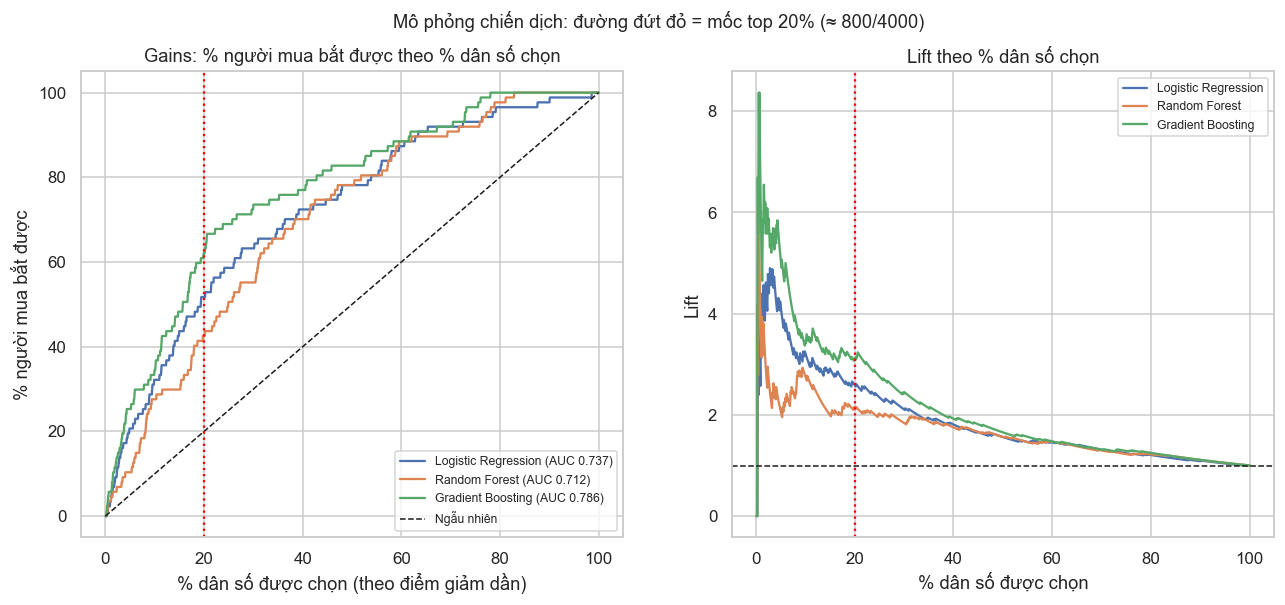

Tại top 20% trên tập validation:
  Logistic Regression   : bắt được 45/87 người mua (51.7%) | lift 2.59x
  Random Forest         : bắt được 37/87 người mua (42.5%) | lift 2.13x
  Gradient Boosting     : bắt được 54/87 người mua (62.1%) | lift 3.10x


In [28]:
# Đường lift / gains mô phỏng "chọn top K%" (mục tiêu top 20% ~ 800/4000)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
n = len(yva); total_pos = yva.sum(); frac = np.arange(1, n+1)/n
for name, p in proba.items():
    order = np.argsort(-p)
    cum_pos = np.cumsum(yva.values[order])
    gains = cum_pos/total_pos
    lift = gains/frac
    axes[0].plot(frac*100, gains*100, label=f"{name} (AUC {auc[name]:.3f})")
    axes[1].plot(frac*100, lift, label=name)
axes[0].plot([0, 100], [0, 100], "k--", lw=1, label="Ngẫu nhiên")
axes[0].axvline(20, color="red", ls=":"); axes[0].set_title("Gains: % người mua bắt được theo % dân số chọn")
axes[0].set_xlabel("% dân số được chọn (theo điểm giảm dần)"); axes[0].set_ylabel("% người mua bắt được"); axes[0].legend(fontsize=8)
axes[1].axhline(1, color="k", ls="--", lw=1); axes[1].axvline(20, color="red", ls=":")
axes[1].set_title("Lift theo % dân số chọn"); axes[1].set_xlabel("% dân số được chọn"); axes[1].set_ylabel("Lift"); axes[1].legend(fontsize=8)
plt.suptitle("Mô phỏng chiến dịch: đường đứt đỏ = mốc top 20% (≈ 800/4000)", fontsize=12)
savefig("08b_lift_gains_curve"); plt.show()

# In hiệu quả tại mốc top 20%
k = int(0.20 * n)
print("Tại top 20% trên tập validation:")
for name, p in proba.items():
    order = np.argsort(-p)[:k]
    captured = yva.values[order].sum()
    print(f"  {name:22s}: bắt được {captured}/{int(total_pos)} người mua "
          f"({captured/total_pos*100:.1f}%) | lift {captured/total_pos/0.20:.2f}x")

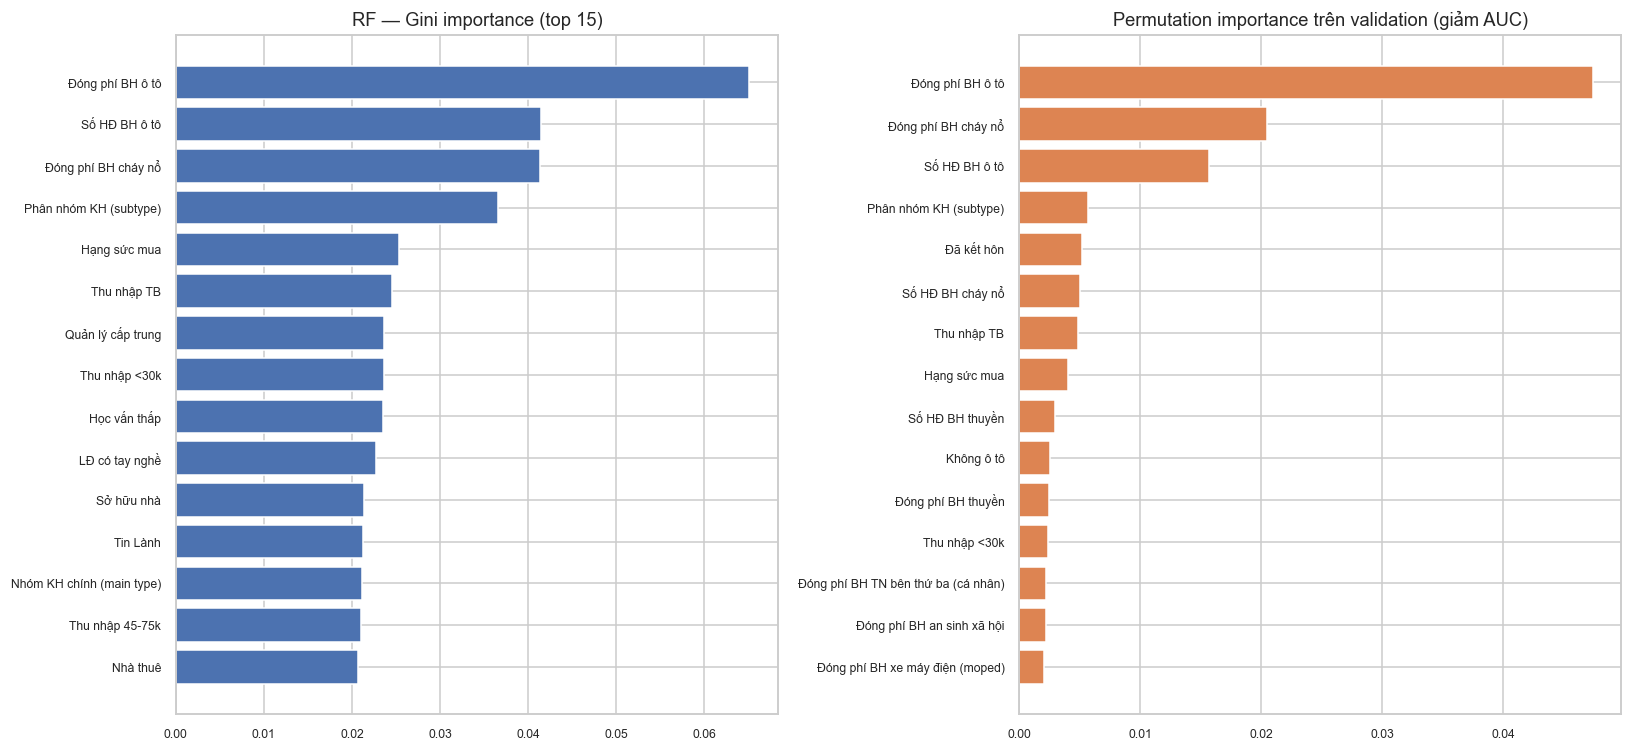

In [29]:
# Feature importance (Random Forest) + permutation importance
from sklearn.inspection import permutation_importance
rf = models["Random Forest"]
imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)

perm = permutation_importance(rf, Xva, yva, scoring="roc_auc", n_repeats=5,
                              random_state=42, n_jobs=1)
perms = pd.Series(perm.importances_mean, index=FEATURES).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
t1 = imp.head(15)
axes[0].barh([disp(c) for c in t1.index][::-1], t1.values[::-1], color="#4c72b0")
axes[0].set_title("RF — Gini importance (top 15)"); axes[0].tick_params(labelsize=8)
t2 = perms.head(15)
axes[1].barh([disp(c) for c in t2.index][::-1], t2.values[::-1], color="#dd8452")
axes[1].set_title("Permutation importance trên validation (giảm AUC)"); axes[1].tick_params(labelsize=8)
plt.tight_layout(); savefig("08c_feature_importance"); plt.show()

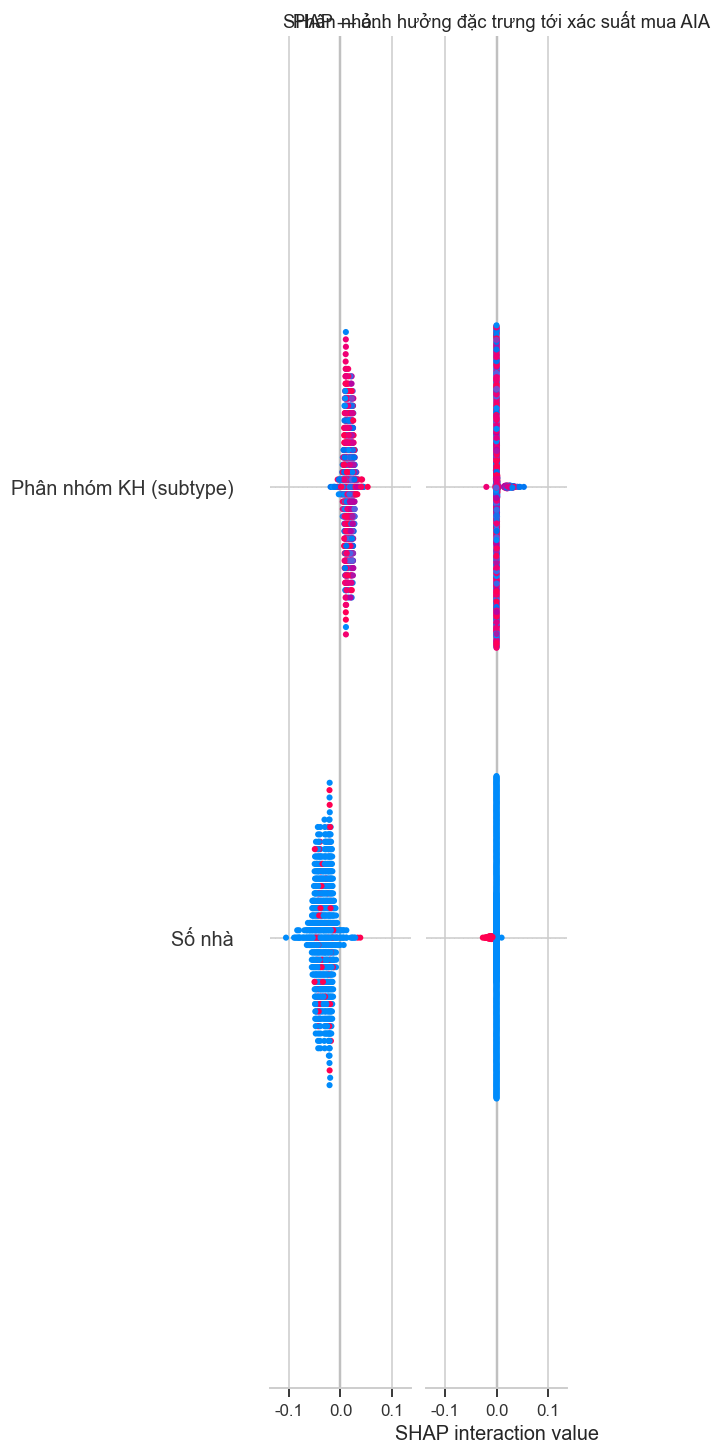

Đã vẽ SHAP summary.


In [30]:
# SHAP (tùy chọn) — chỉ chạy nếu đã cài shap; nếu không sẽ bỏ qua an toàn
try:
    import shap
    expl = shap.TreeExplainer(rf)
    samp = Xva.sample(min(800, len(Xva)), random_state=0)
    sv = expl.shap_values(samp)
    sv1 = sv[1] if isinstance(sv, list) else sv
    shap.summary_plot(sv1, samp, feature_names=[disp(c) for c in FEATURES], show=False, max_display=15)
    plt.title("SHAP — ảnh hưởng đặc trưng tới xác suất mua AIA")
    savefig("08d_shap_summary"); plt.show()
    print("Đã vẽ SHAP summary.")
except Exception as e:
    print("Bỏ qua SHAP (chưa cài 'shap' hoặc lỗi):", type(e).__name__, str(e)[:120])
    print("Cài bằng: pip install shap  — rồi chạy lại cell này để có biểu đồ giải thích chi tiết hơn.")

## 9. Tổng kết & chỉ mục biểu đồ cho slide

**Phát hiện chính (điền/đối chiếu khi chạy):**
- Nhãn rất mất cân bằng (~6% mua) → bài toán **xếp hạng top-800**, đo bằng AUC & lift, không dùng accuracy.
- Dữ liệu sạch (không thiếu, không lỗi dải), gần như toàn bộ là **biến mã hoá khoảng/đếm**, **rất thưa** ở nhóm bảo hiểm khác.
- Nhóm **Đóng phí ↔ Số HĐ** trùng lặp mạnh → có thể giản lược đặc trưng.
- Tín hiệu mua mạnh nhất đến từ **việc đã sở hữu các bảo hiểm khác** (đặc biệt liên quan ô tô/cháy nổ/tài sản) cùng **sức mua & tầng lớp xã hội** — xem biểu đồ lift & importance.
- Một số **phân khúc khách hàng (A1/A3)** có tỉ lệ mua cao vượt trội → mục tiêu ưu tiên cho chiến dịch.

**Bổ sung (Section 10):**
- **Test KHÔNG lệch** so với train (adversarial AUC≈0.50, PSI<0.02) → CV nội bộ đáng tin cậy, không cần điều chỉnh phân phối.
- **Hồ sơ gần như duy nhất** → tra cứu khớp-chính-xác ≈ ngẫu nhiên; mô hình thắng nhờ **tổng quát hoá** (baseline hits@20%≈162, lift ~2.3x).
- **Độ rộng sở hữu BH** và **flag(>0)** giữ phần lớn tín hiệu → biện minh các đặc trưng `agg_n_*`/`flag_*` cho FE.

Cell dưới in tóm tắt số liệu và liệt kê toàn bộ biểu đồ đã lưu (kèm gợi ý slide).

In [31]:
print("="*64)
print("TÓM TẮT EDA — VPINS AIA CHALLENGE")
print("="*64)
print(f"Train: {train.shape[0]} KH x {len(FEATURES)} đặc trưng | Test: {test.shape[0]} KH")
print(f"Tỉ lệ mua AIA: {base_rate*100:.2f}% (mất cân bằng ~1:{(1-base_rate)/base_rate:.1f})")
print(f"Giá trị thiếu: {int(train.isna().sum().sum())} | Mô hình tốt nhất: {best_name} (AUC {auc[best_name]:.3f})")
print("\nTop 8 đặc trưng (mutual information):")
for c in mi.head(8).index:
    print(f"  - {disp(c)}  (MI={mi[c]:.4f}, rho={corr_t[c]:+.3f})")

print("\nGỢI Ý SLIDE — biểu đồ đã lưu trong figures/:")
slide_map = {
 "03_target_distribution": "Slide bối cảnh: độ mất cân bằng",
 "04d_zero_inflation": "Slide dữ liệu: độ thưa của hồ sơ bảo hiểm",
 "05a_corr_with_target": "Slide insight: yếu tố liên quan việc mua",
 "05c_lift_top_features": "Slide insight: lift theo mức (mạnh nhất)",
 "07a_rate_by_segment": "Slide actionable: nhắm phân khúc nào",
 "07b_segment_heatmaps": "Slide actionable: bản đồ nhiệt phân khúc",
 "08b_lift_gains_curve": "Slide kết quả: hiệu quả chọn top-800",
 "08c_feature_importance": "Slide giải thích: yếu tố quan trọng của mô hình",
}
for f in sorted(FIG_DIR.glob("*.png")):
    note = slide_map.get(f.stem, "")
    print(f"  - {f.name:34s} {note}")

TÓM TẮT EDA — VPINS AIA CHALLENGE
Train: 5822 KH x 85 đặc trưng | Test: 4000 KH
Tỉ lệ mua AIA: 5.98% (mất cân bằng ~1:15.7)
Giá trị thiếu: 0 | Mô hình tốt nhất: Gradient Boosting (AUC 0.786)

Top 8 đặc trưng (mutual information):
  - Đóng phí BH ô tô  (MI=0.0167, rho=+0.164)
  - Đóng phí BH cháy nổ  (MI=0.0118, rho=+0.101)
  - Số HĐ BH ô tô  (MI=0.0118, rho=+0.149)
  - Phân nhóm KH (subtype)  (MI=0.0106, rho=-0.058)
  - Nhóm KH chính (main type)  (MI=0.0076, rho=-0.062)
  - Thu nhập TB  (MI=0.0065, rho=+0.100)
  - Hạng sức mua  (MI=0.0061, rho=+0.095)
  - Thu nhập <30k  (MI=0.0049, rho=-0.081)

GỢI Ý SLIDE — biểu đồ đã lưu trong figures/:
  - 02_train_test_drift.png            
  - 02b_duplicates_keep_decision.png   
  - 03_target_distribution.png         Slide bối cảnh: độ mất cân bằng
  - 04a_socio_main.png                 
  - 04b_subtype_distribution.png       
  - 04c_socio_pct_grid.png             
  - 04d_zero_inflation.png             Slide dữ liệu: độ thưa của hồ sơ bảo hiểm
 

## 10. Insight nâng cao trước Feature Engineering

Năm phân tích bổ sung để định hướng FE & validation có cơ sở (không làm mò):

- **10a. Adversarial validation + PSI** — train và test có **lệch phân phối** không (và do feature nào)? Quyết định CV nội bộ có đáng tin (đề bài nói test là "người *likely to buy*" → cần kiểm chứng bằng dữ liệu).
- **10b. Độ phân giải & tổng quát hoá** — so **tra cứu hồ sơ khớp-chính-xác** vs mô hình: đo độ thưa/mịn của đặc trưng và vì sao cần mô hình *tổng quát hoá* (không phải tra cứu).
- **10c. Tín hiệu bắc cầu FE** — độ rộng sở hữu (`agg_n_*`), flag(>0) vs mức ordinal (`flag_*`), và tính đơn điệu → biện minh các đặc trưng kỹ thuật trước khi tạo.
- **10d. AUC đơn biến + bootstrap** — xếp hạng sức mạnh từng đặc trưng theo AUC (threshold-free) kèm khoảng tin cậy → tín hiệu nào *bền*.
- **10e. Baseline bằng CV trung thực** — `hits@20% ± std` (RepeatedStratifiedKFold) thay cho 1 split; cho thấy mô hình **vượt xa** tra cứu hồ sơ (10b).

Adversarial AUC (phan biet train vs test): RF=0.504 | LogReg=0.512
AUC ~0.5 => train/test giong nhau; AUC cang cao => test cang lech khoi train.


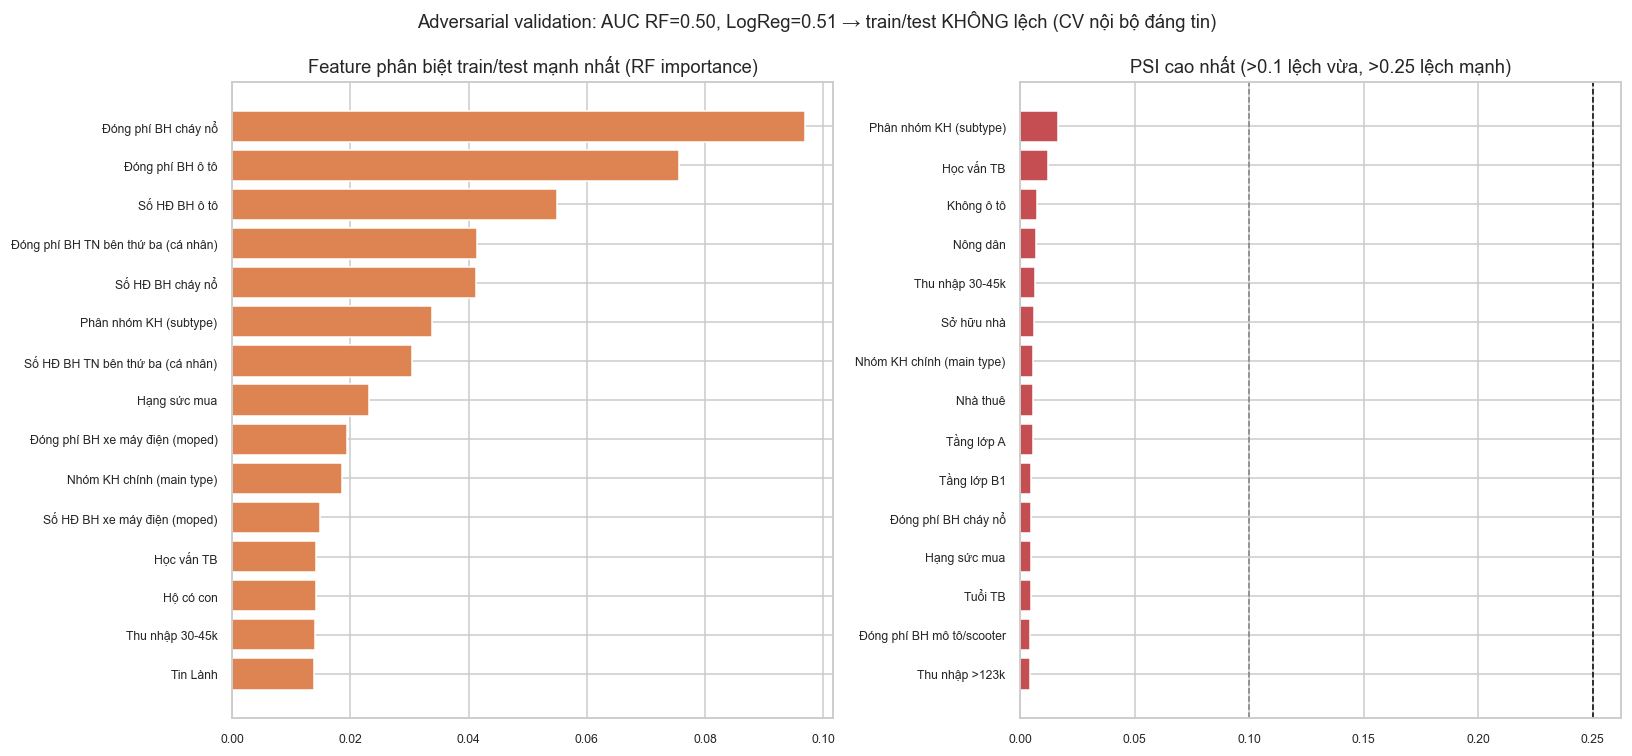

Top 8 feature lệch train/test (PSI):
  Phân nhóm KH (subtype)                   PSI=0.017
  Học vấn TB                               PSI=0.012
  Không ô tô                               PSI=0.008
  Nông dân                                 PSI=0.007
  Thu nhập 30-45k                          PSI=0.006
  Sở hữu nhà                               PSI=0.006
  Nhóm KH chính (main type)                PSI=0.006
  Nhà thuê                                 PSI=0.006


In [32]:
# ===== 10a. Adversarial validation train vs test + PSI =====
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import roc_auc_score

_Xadv = pd.concat([train[FEATURES], test[FEATURES]], ignore_index=True)
_yadv = np.r_[np.zeros(len(train)), np.ones(len(test))]
_cv = StratifiedKFold(5, shuffle=True, random_state=42)

_rf = RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42, class_weight="balanced_subsample")
_p_rf = cross_val_predict(_rf, _Xadv, _yadv, cv=_cv, method="predict_proba", n_jobs=-1)[:, 1]
_auc_rf = roc_auc_score(_yadv, _p_rf)
_lr = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight="balanced"))
_p_lr = cross_val_predict(_lr, _Xadv, _yadv, cv=_cv, method="predict_proba", n_jobs=-1)[:, 1]
_auc_lr = roc_auc_score(_yadv, _p_lr)
print("Adversarial AUC (phan biet train vs test): RF=%.3f | LogReg=%.3f" % (_auc_rf, _auc_lr))
print("AUC ~0.5 => train/test giong nhau; AUC cang cao => test cang lech khoi train.")

_rf.fit(_Xadv, _yadv)
_impadv = pd.Series(_rf.feature_importances_, index=FEATURES).sort_values(ascending=False)

def _psi(col):
    a = train[col].value_counts(normalize=True)
    b = test[col].value_counts(normalize=True)
    lv = sorted(set(a.index) | set(b.index))
    a = a.reindex(lv, fill_value=0).clip(lower=1e-4)
    b = b.reindex(lv, fill_value=0).clip(lower=1e-4)
    return float(((b - a) * np.log(b / a)).sum())
_psi_s = pd.Series({c: _psi(c) for c in FEATURES}).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
t1 = _impadv.head(15)
axes[0].barh([disp(c) for c in t1.index][::-1], t1.values[::-1], color="#dd8452")
axes[0].set_title("Feature phân biệt train/test mạnh nhất (RF importance)")
axes[0].tick_params(labelsize=8)
t2 = _psi_s.head(15)
axes[1].barh([disp(c) for c in t2.index][::-1], t2.values[::-1], color="#c44e52")
axes[1].axvline(0.1, color="gray", ls="--", lw=1); axes[1].axvline(0.25, color="black", ls="--", lw=1)
axes[1].set_title("PSI cao nhất (>0.1 lệch vừa, >0.25 lệch mạnh)")
axes[1].tick_params(labelsize=8)
_verdict = "KHÔNG lệch (CV nội bộ đáng tin)" if _auc_rf < 0.55 else "CÓ lệch — chú ý validation"
plt.suptitle("Adversarial validation: AUC RF=%.2f, LogReg=%.2f → train/test %s" % (_auc_rf, _auc_lr, _verdict), fontsize=12)
plt.tight_layout(); savefig("10a_adversarial_validation"); plt.show()
print("Top 8 feature lệch train/test (PSI):")
for c in _psi_s.head(8).index:
    print("  %-40s PSI=%.3f" % (disp(c), _psi_s[c]))

Top-1165 (= 20% cua 5822) tren TRAIN — so nguoi mua bat duoc:
  Profile duy nhat: 5171 / 5822 dong  => ho so rat 'min'/thua
  Ngau nhien (ky vong)               : 70 / 348
  Tra cuu ho so khop-chinh-xac (CV)  : 78 / 348  (lift 1.12x) ~ ngau nhien
  Ghi nho in-sample (perfect)        : 348 / 348  (KHONG dat duoc ngoai mau)


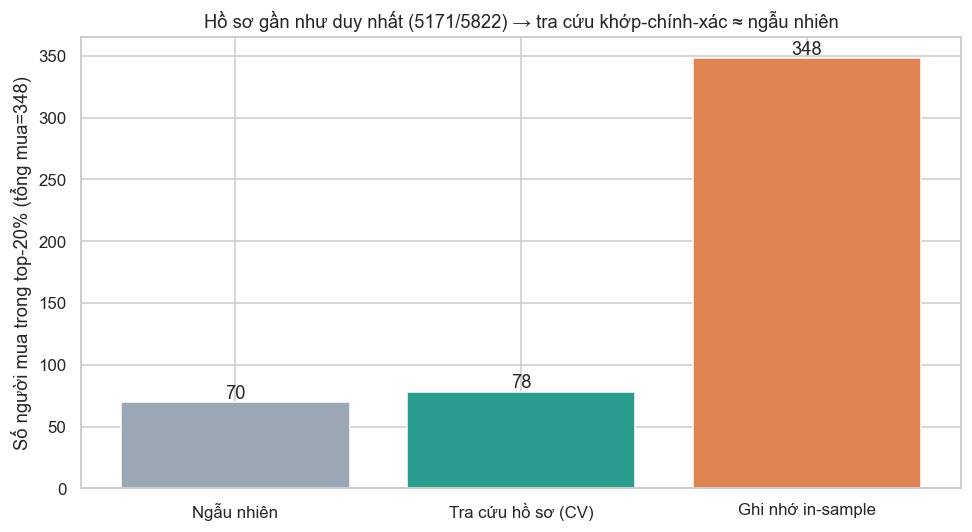

=> Khong the 'tra cuu' — model phai TONG QUAT HOA theo lan can (xem 10e: baseline ~162 >> 78).


In [33]:
# ===== 10b. Độ phân giải đặc trưng: tra cứu hồ sơ vs tổng quát hoá =====
from sklearn.model_selection import StratifiedKFold
from src.metrics import topk_hits, lift_at_k, TOPK_FRAC

_y = train[TARGET].astype(int).values
_oof_oracle = np.zeros(len(train))
_skf = StratifiedKFold(5, shuffle=True, random_state=42)
for _tr, _va in _skf.split(train, _y):
    _gmap = train.iloc[_tr].groupby(FEATURES)[TARGET].mean().to_dict()
    _b = _y[_tr].mean()
    _vt = train.iloc[_va][FEATURES].itertuples(index=False, name=None)
    _oof_oracle[_va] = [_gmap.get(k, _b) for k in _vt]

_perfect = train.groupby(FEATURES)[TARGET].transform("mean").values
_pos = int(_y.sum()); _k = int(np.ceil(TOPK_FRAC * len(_y)))
_n_uniq = train[FEATURES].drop_duplicates().shape[0]
_hits_cv = topk_hits(_y, _oof_oracle)
_hits_perfect = topk_hits(_y, _perfect)
_hits_random = TOPK_FRAC * _pos

print("Top-%d (= %.0f%% cua %d) tren TRAIN — so nguoi mua bat duoc:" % (_k, TOPK_FRAC*100, len(_y)))
print("  Profile duy nhat: %d / %d dong  => ho so rat 'min'/thua" % (_n_uniq, len(_y)))
print("  Ngau nhien (ky vong)               : %.0f / %d" % (_hits_random, _pos))
print("  Tra cuu ho so khop-chinh-xac (CV)  : %d / %d  (lift %.2fx) ~ ngau nhien" % (_hits_cv, _pos, lift_at_k(_y, _oof_oracle)))
print("  Ghi nho in-sample (perfect)        : %d / %d  (KHONG dat duoc ngoai mau)" % (_hits_perfect, _pos))

fig, ax = plt.subplots(figsize=(9, 5))
_vals = [_hits_random, _hits_cv, _hits_perfect]
_names = ["Ngẫu nhiên", "Tra cứu hồ sơ (CV)", "Ghi nhớ in-sample"]
b = ax.bar(_names, _vals, color=["#9aa7b5", "#2a9d8f", "#dd8452"])
ax.bar_label(b, fmt="%.0f")
ax.set_ylabel("Số người mua trong top-20%% (tổng mua=%d)" % _pos)
ax.set_title("Hồ sơ gần như duy nhất (%d/%d) → tra cứu khớp-chính-xác ≈ ngẫu nhiên" % (_n_uniq, len(_y)))
plt.tight_layout(); savefig("10b_oracle_ceiling"); plt.show()
print("=> Khong the 'tra cuu' — model phai TONG QUAT HOA theo lan can (xem 10e: baseline ~162 >> 78).")

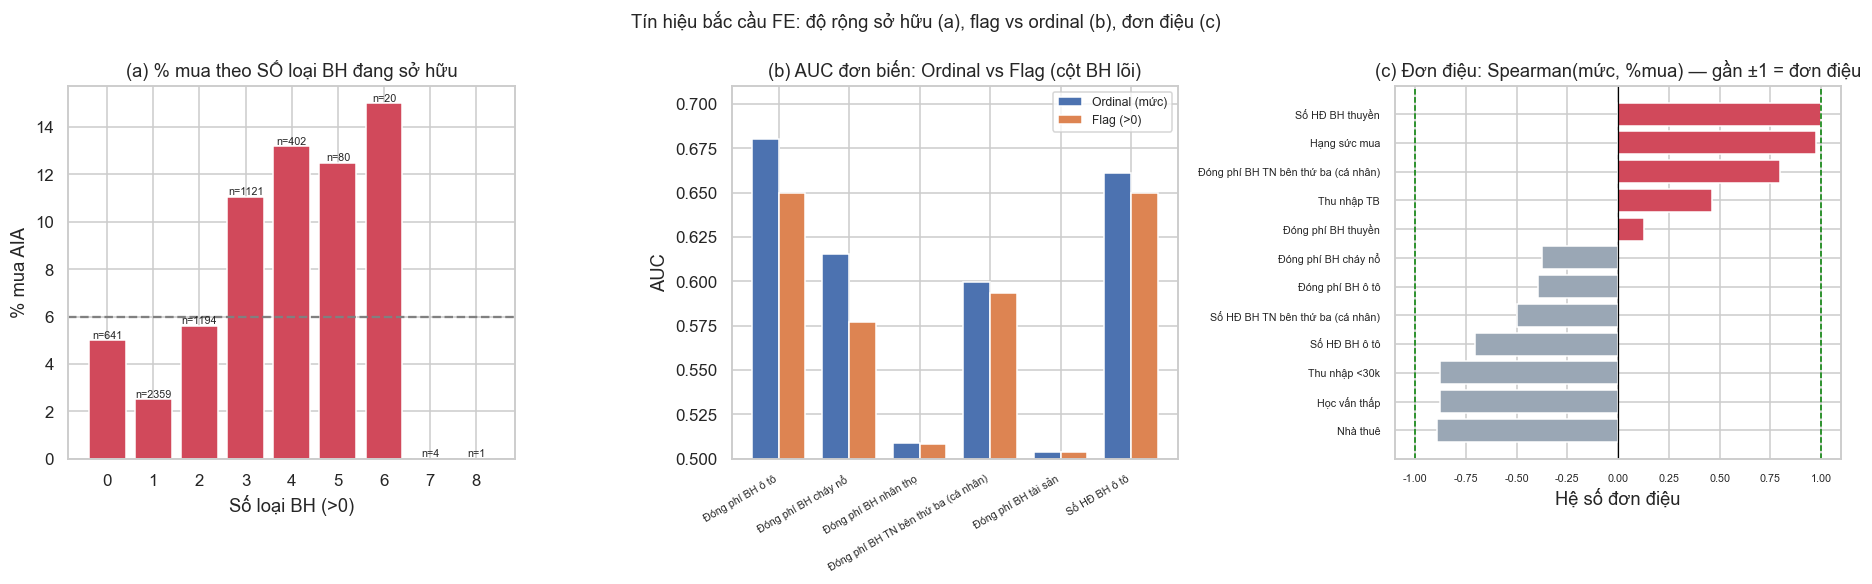

(a) %% mua tang theo so loai BH so huu => agg_n_* huu ich.
(b) Flag(>0) giu gan bang AUC cua muc ordinal => flag_* gon ma manh.
(c) Hau het feature top don dieu => dung raw/ordinal hop ly cho cay; subtype/main type de TargetEncoder lo.


In [34]:
# ===== 10c. Tin hieu bac cau FE: do rong so huu, flag vs ordinal, don dieu =====
from sklearn.metrics import roc_auc_score
from scipy.stats import spearmanr
_y = train[TARGET].astype(int).values
_base = _y.mean()

# (a) so loai BH dang so huu (NUMBER > 0) -> ti le mua
_n_types = (train[NUMBER] > 0).sum(axis=1)
_g = train.assign(_nt=_n_types).groupby("_nt")[TARGET].agg(rate="mean", n="count")

# (b) flag(>0) vs muc ordinal — AUC don bien cho cac cot BH loi
_core = ["47", "59", "55", "44", "63", "68"]
_rows = []
for c in _core:
    a1 = roc_auc_score(_y, train[c].values); a1 = max(a1, 1 - a1)
    fl = (train[c] > 0).astype(int).values
    a2 = roc_auc_score(_y, fl); a2 = max(a2, 1 - a2)
    _rows.append((disp(c), a1, a2))
_fb = pd.DataFrame(_rows, columns=["feat", "ordinal", "flag"])

# (c) don dieu: spearman(muc, ti le mua) cho top 12 feature theo |corr voi target|
_absrho = train[FEATURES].apply(lambda s: abs(spearmanr(s, _y).statistic)).sort_values(ascending=False)
_topf = _absrho.head(12).index.tolist()
_mono = {}
for c in _topf:
    rl = train.groupby(c)[TARGET].mean()
    _mono[disp(c)] = spearmanr(rl.index, rl.values).statistic
_mono = pd.Series(_mono).sort_values()

fig, axes = plt.subplots(1, 3, figsize=(17, 5.4))
axes[0].bar(_g.index.astype(str), _g["rate"]*100, color="#d1495b")
axes[0].axhline(_base*100, color="gray", ls="--")
for i, (r, n_) in enumerate(zip(_g["rate"]*100, _g["n"])):
    axes[0].text(i, r, "n=%d" % n_, ha="center", va="bottom", fontsize=7)
axes[0].set_title("(a) % mua theo SỐ loại BH đang sở hữu")
axes[0].set_xlabel("Số loại BH (>0)"); axes[0].set_ylabel("% mua AIA")

_x = np.arange(len(_fb)); _w = 0.38
axes[1].bar(_x - _w/2, _fb["ordinal"], _w, label="Ordinal (mức)", color="#4c72b0")
axes[1].bar(_x + _w/2, _fb["flag"], _w, label="Flag (>0)", color="#dd8452")
axes[1].set_xticks(_x); axes[1].set_xticklabels(_fb["feat"], rotation=30, ha="right", fontsize=7)
axes[1].set_ylim(0.5, _fb[["ordinal", "flag"]].values.max() + 0.03)
axes[1].set_title("(b) AUC đơn biến: Ordinal vs Flag (cột BH lõi)")
axes[1].set_ylabel("AUC"); axes[1].legend(fontsize=8)

axes[2].barh(_mono.index, _mono.values, color=["#d1495b" if v > 0 else "#9aa7b5" for v in _mono.values])
axes[2].axvline(0, color="black", lw=0.8); axes[2].axvline(1, color="green", ls="--", lw=1); axes[2].axvline(-1, color="green", ls="--", lw=1)
axes[2].set_title("(c) Đơn điệu: Spearman(mức, %mua) — gần ±1 = đơn điệu")
axes[2].set_xlabel("Hệ số đơn điệu"); axes[2].tick_params(labelsize=7)
plt.suptitle("Tín hiệu bắc cầu FE: độ rộng sở hữu (a), flag vs ordinal (b), đơn điệu (c)", fontsize=12)
plt.tight_layout(); savefig("10c_fe_signal"); plt.show()
print("(a) %% mua tang theo so loai BH so huu => agg_n_* huu ich.")
print("(b) Flag(>0) giu gan bang AUC cua muc ordinal => flag_* gon ma manh.")
print("(c) Hau het feature top don dieu => dung raw/ordinal hop ly cho cay; subtype/main type de TargetEncoder lo.")

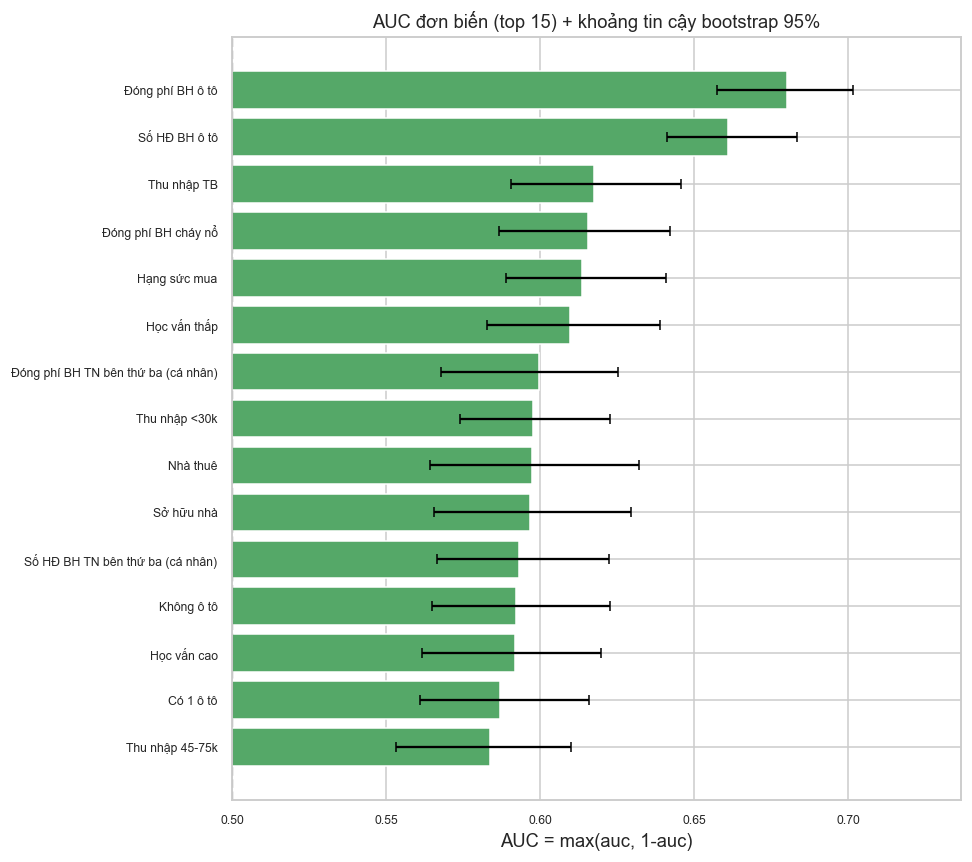

Feature don bien manh & ben nhat (AUC [KTC 95%]):
  Đóng phí BH ô tô                         AUC=0.680  [0.658, 0.702]
  Số HĐ BH ô tô                            AUC=0.661  [0.641, 0.683]
  Thu nhập TB                              AUC=0.617  [0.591, 0.646]
  Đóng phí BH cháy nổ                      AUC=0.615  [0.587, 0.642]
  Hạng sức mua                             AUC=0.614  [0.589, 0.641]
  Học vấn thấp                             AUC=0.610  [0.583, 0.639]
  Đóng phí BH TN bên thứ ba (cá nhân)      AUC=0.600  [0.568, 0.625]
  Thu nhập <30k                            AUC=0.598  [0.574, 0.623]


In [35]:
# ===== 10d. Suc manh don bien bang AUC + on dinh bootstrap =====
from sklearn.metrics import roc_auc_score
_y = train[TARGET].astype(int).values
def _uauc(v, y):
    a = roc_auc_score(y, v); return max(a, 1 - a)
_auc_all = pd.Series({c: _uauc(train[c].values, _y) for c in FEATURES}).sort_values(ascending=False)
_top = _auc_all.head(15)

_rng = np.random.RandomState(0); B = 200; n = len(_y)
_lo, _hi = {}, {}
for c in _top.index:
    v = train[c].values; bs = []
    for _ in range(B):
        idx = _rng.randint(0, n, n)
        a = roc_auc_score(_y[idx], v[idx]); bs.append(max(a, 1 - a))
    _lo[c], _hi[c] = np.percentile(bs, [2.5, 97.5])

fig, ax = plt.subplots(figsize=(9, 8))
yp = np.arange(len(_top))[::-1]
ax.barh(yp, _top.values, color="#55a868")
lo_arr = np.array([_lo[c] for c in _top.index]); hi_arr = np.array([_hi[c] for c in _top.index])
ax.errorbar(_top.values, yp, xerr=np.vstack([_top.values - lo_arr, hi_arr - _top.values]),
            fmt="none", ecolor="black", capsize=3)
ax.set_yticks(yp); ax.set_yticklabels([disp(c) for c in _top.index])
ax.set_xlim(0.5, None); ax.axvline(0.5, color="gray", ls="--")
ax.set_title("AUC đơn biến (top 15) + khoảng tin cậy bootstrap 95%")
ax.set_xlabel("AUC = max(auc, 1-auc)"); ax.tick_params(labelsize=8)
plt.tight_layout(); savefig("10d_univariate_auc"); plt.show()
print("Feature don bien manh & ben nhat (AUC [KTC 95%]):")
for c in _top.head(8).index:
    print("  %-40s AUC=%.3f  [%.3f, %.3f]" % (disp(c), _top[c], _lo[c], _hi[c]))

LogReg   OOF: AUC=0.735 | hits@20%=162 (+-4.1) | lift=2.33
HistGB   OOF: AUC=0.720 | hits@20%=161 (+-4.5) | lift=2.31


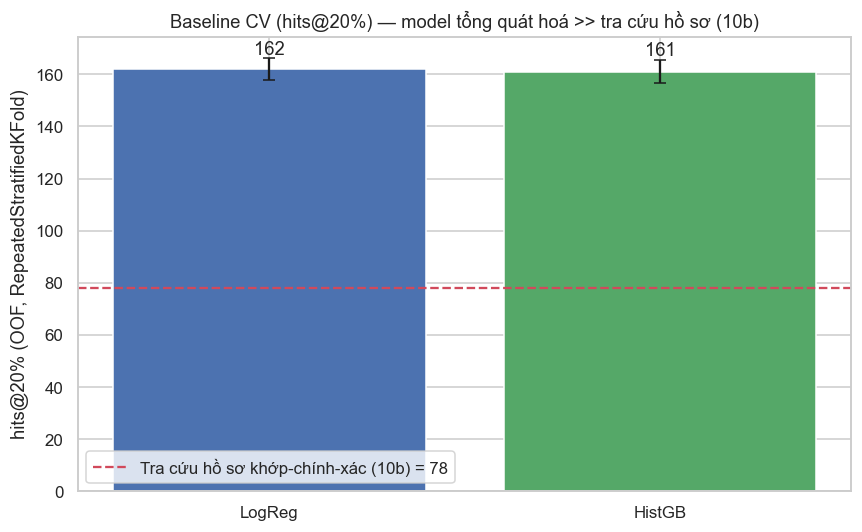

Model baseline ~162 >> tra cuu ho so 78 => tong quat hoa co gia tri; du dia tiep: FE + tuning + ensemble.


In [36]:
# ===== 10e. Baseline danh gia bang CV trung thuc (hits@20% +- std) =====
from src.cv import oof_proba
from src.metrics import summarize
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier

_yb = train[TARGET].astype(int)
_specs = {
 "LogReg": {"est": LogisticRegression(max_iter=2000, class_weight="balanced"), "scale": True, "te": True},
 "HistGB": {"est": HistGradientBoostingClassifier(learning_rate=0.05, max_iter=300, class_weight="balanced", random_state=42), "scale": False, "te": True},
}
_res = {}
for nm, sp in _specs.items():
    o, per = oof_proba(sp, train, _yb, FEATURES, n_splits=5, n_repeats=3)
    s = summarize(_yb, o); s["hits_std"] = float(np.std(per)); _res[nm] = s
    print("%-8s OOF: AUC=%.3f | hits@20%%=%d (+-%.1f) | lift=%.2f" % (nm, s["AUC"], s["hits@20%"], s["hits_std"], s["lift@20%"]))

fig, ax = plt.subplots(figsize=(8, 5))
_nm = list(_res.keys()); _h = [_res[n]["hits@20%"] for n in _nm]; _e = [_res[n]["hits_std"] for n in _nm]
b = ax.bar(_nm, _h, yerr=_e, capsize=4, color=["#4c72b0", "#55a868"])
ax.bar_label(b, fmt="%.0f")
try:
    ax.axhline(_hits_cv, color="#d1495b", ls="--", lw=1.5, label="Tra cứu hồ sơ khớp-chính-xác (10b) = %d" % _hits_cv)
    ax.legend()
except Exception:
    pass
ax.set_ylabel("hits@20% (OOF, RepeatedStratifiedKFold)")
ax.set_title("Baseline CV (hits@20%) — model tổng quát hoá >> tra cứu hồ sơ (10b)")
plt.tight_layout(); savefig("10e_cv_baseline"); plt.show()
print("Model baseline ~162 >> tra cuu ho so 78 => tong quat hoa co gia tri; du dia tiep: FE + tuning + ensemble.")

**Kết luận Section 10 → định hướng FE/model:**
- **10a** AUC≈0.50, PSI<0.02 → **test KHÔNG lệch** so với train: CV nội bộ (RepeatedStratifiedKFold) phản ánh đúng, **không cần** reweight/điều chỉnh phân phối.
- **10b + 10e** Hồ sơ gần như duy nhất → **tra cứu khớp-chính-xác ≈ ngẫu nhiên (~78)**; mô hình baseline **~162 (lift 2.3x)** thắng xa nhờ **tổng quát hoá**. Ghi nhớ in-sample (348) không đạt được ngoài mẫu. Dư địa nâng baseline: FE + tuning + ensemble.
- **10c** xác nhận nên tạo `agg_n_*` (độ rộng sở hữu) và `flag_*`; feature đơn điệu → cây dùng raw tốt, cột cardinal cao (subtype/main type) để `TargetEncoder` xử lý.
- **10d** chỉ ra nhóm đặc trưng tín hiệu *bền* (Đóng phí/Số HĐ ô tô, thu nhập, sức mua, cháy nổ) — ưu tiên giữ khi feature selection.